# 06 — Better models: deeper tuning, a neural network, and an honest ensemble

**Kenya maize (One Acre Fund MEL Agronomic Survey, 2016–2020)**

Notebook 05 tuned four tree families and closed with a list of recommendations. This
notebook acts on them. It rebuilds the selection protocol so that nothing is chosen
on the 2020 holdout, searches four tree families over a wider space that now includes
the *representation* itself, adds a fifth family — an entity-embedding neural
network — and combines them with weights fitted out-of-time instead of an unweighted
mean chosen after the fact.

### What is different from notebook 05

| | Notebook 05 | Here |
|---|---|---|
| Hyperparameter selection | one inner season (2019) | rolling-origin inner CV (2018 **and** 2019) |
| Weather-PC rank | picked on the 2020 holdout | searched per model on inner seasons |
| Categorical handling | native categories / integer codes | + out-of-fold smoothed target encoding, searched |
| Target treatment | raw kg/ha | raw / log / winsorised / year-demeaned, searched |
| Model families | LightGBM, XGBoost, RF, ExtraTrees | + entity-embedding MLP, + ridge (as a control) |
| Per family | best single configuration | average of the top 5 configurations |
| Combination | unweighted mean of four | non-negative weights fitted on inner seasons |
| Reported metrics | R², MAE, RMSE, ρ, spread | + interval coverage, district level, per-family diagnostics |

### The result, stated up front

| Measured on the 2020 holdout | nb 04 stock | nb 05 ensemble | **this notebook** |
|---|---|---|---|
| R² (plot level) | +0.1031 | +0.1674 | **+0.1640** |
| MAE (kg/ha) | 1,151 | 1,116 | **1,120** |
| Mean R² over 2018 / 2019 / 2020 | — | +0.143 | **+0.164** |
| District-mean R² (≥100 plots) | 0.455 | 0.61–0.67 | **0.661** |
| 80% prediction interval coverage | — | — | **75.3%** |
| Anything chosen on the holdout? | no | **yes** (PC rank, blend) | **no** |

**Plot-level R² did not improve, and that is the expected result** — notebook 05 measured
the ceiling at 0.177, so there was 0.01 left to win and this notebook wins about none of
it. What did improve is the average across seasons (+0.143 → +0.164), the district-level
number the project should actually be reporting, calibrated prediction intervals where
there were none, and the integrity of the selection procedure: every choice here is made
on 2018–2019 and the holdout is scored once.

The neural network is worth the section it gets even though it does not win: it is the
least correlated member of the pool, and getting it to work out-of-time exposed three
failure modes that within-season cross-validation cannot see.

## 0 · Setup

In [1]:
import os, time, json, warnings
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))
import contextlib, io as _io
with contextlib.redirect_stderr(_io.StringIO()):
    try:
        from joblib.externals.loky.backend import context as _lk
        _lk._count_physical_cores()
    except Exception:
        pass

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
from scipy import stats
from scipy.optimize import nnls

import lightgbm as lgb, xgboost as xgb
import torch, torch.nn as nn
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder, QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
torch.set_num_threads(os.cpu_count() or 4)

ROOT = Path.cwd()
while not (ROOT / "data" / "features").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
FEATURES, CLEANED = ROOT / "data" / "features", ROOT / "data" / "cleaned"
TARGET, HOLDOUT_YEAR = "yield_kg_ph", 2020

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RED, VIOLET        = "#e34948", "#4a3aa7"
INK, INK2, MUTED   = "#0b0b0b", "#52514e", "#b4b3ad"
SURFACE            = "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.edgecolor": MUTED,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "legend.frameon": False,
    "figure.dpi": 110,
})
def style(ax, title=None, xlabel=None, ylabel=None, xgrid=False, ygrid=True):
    if title:  ax.set_title(title, loc="left", pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(axis="x" if xgrid else "y", visible=xgrid or ygrid)
    ax.set_axisbelow(True)
    return ax

print(f"lightgbm {lgb.__version__} | xgboost {xgb.__version__} | torch {torch.__version__}")

lightgbm 4.7.0 | xgboost 3.3.0 | torch 2.14.0+cpu


In [2]:
def restore_dtypes(df):
    """Booleans round-trip through CSV as strings; cast the whole block to float
    so every downstream step sees one representation (as in notebooks 04-05)."""
    for c in df.columns:
        if df[c].dtype == bool:
            df[c] = df[c].astype(float)
        elif df[c].dtype == object:
            v = set(df[c].dropna().unique())
            if v and v <= {True, False, "True", "False"}:
                df[c] = df[c].map({True: 1.0, False: 0.0, "True": 1.0, "False": 0.0}).astype(float)
    return df

full = restore_dtypes(pd.read_csv(FEATURES / "kenya_maize_features_full.csv", low_memory=False))
rec  = pd.read_csv(FEATURES / "kenya_maize_recommended_features.csv")
man  = pd.read_csv(FEATURES / "kenya_maize_feature_manifest.csv").set_index("feature")

FEATS = rec.feature.tolist()
CATS  = [c for c in FEATS if full[c].dtype == object]
for c in CATS:
    full[c] = full[c].astype("category")

# the full external weather block, of which notebook 03 kept 11 columns
WX   = [c for c in man.index if c in full.columns
        and pd.api.types.is_numeric_dtype(full[c])
        and man.loc[c, "source"] == "external" and man.loc[c, "decision"] == "keep"]
NONW = [c for c in FEATS if c not in WX]

y        = full[TARGET]
is_train = full.year < HOLDOUT_YEAR      # 2016-2019: everything the model may learn from
is_hold  = full.year == HOLDOUT_YEAR     # 2020: scored once per model, chooses nothing
y_hold   = y[is_hold].to_numpy()

# rolling-origin inner validation: fit on all prior seasons, validate on the next one
FOLDS = [(2018, full.year < 2018, full.year == 2018),
         (2019, full.year < 2019, full.year == 2019)]

# every prediction is clipped to the training target range. This is a deployment
# guardrail rather than a tuning choice: it is a no-op for trees, which cannot
# extrapolate, and it stops linear/neural models emitting impossible yields when a
# season falls outside the range they were fitted on (measured in section 7).
LO, HI = float(y[is_train].min()), float(y[is_train].max())
def clip(p): return np.clip(p, LO, HI)

def metrics(pred, actual):
    return dict(r2=r2_score(actual, pred),
                mae=mean_absolute_error(actual, pred),
                rmse=float(np.sqrt(mean_squared_error(actual, pred))))

def report(pred, label, actual=None, store=None):
    m = metrics(pred, y_hold if actual is None else actual); m["model"] = label
    print(f"  {label:44s} R²={m['r2']:+.4f}  MAE={m['mae']:7.0f}  RMSE={m['rmse']:7.0f}")
    if store is not None: store.append(m)
    return m

print(f"{len(FEATS)} features ({len(CATS)} categorical) | weather block {len(WX)} columns")
print(f"train 2016-19 {is_train.sum():,} rows | holdout 2020 {is_hold.sum():,} rows")
print(f"inner folds: fit 2016-17 → validate 2018 ({FOLDS[0][2].sum():,});"
      f"  fit 2016-18 → validate 2019 ({FOLDS[1][2].sum():,})")
print(f"prediction clip range from training years: {LO:,.0f} – {HI:,.0f} kg/ha")

66 features (6 categorical) | weather block 89 columns
train 2016-19 17,484 rows | holdout 2020 6,190 rows
inner folds: fit 2016-17 → validate 2018 (4,245);  fit 2016-18 → validate 2019 (5,372)
prediction clip range from training years: 0 – 10,125 kg/ha


## 1 · What notebook 05 left open

Notebook 05 reached R² = +0.167 on the 2020 holdout and argued — correctly, and with
a measurement — that the plot-level ceiling is about +0.177, because only 17.6% of
plot-level yield variance lies between districts. Nothing here disputes that. But three
of its own recommendations point at work that was not done, and one detail of its
procedure needs repair.

**The repair.** Notebook 05 chose the weather-PC rank by comparing candidate ranks on
the 2020 holdout (§2 of that notebook prints holdout R² for each rank and adopts the
best), and it chose the four-model unweighted mean after seeing every combination's
holdout score. Both are selections made on the test set. Neither is large — §2 below
measures the first at about 0.006 R² — but the whole argument of notebooks 03–05 is
that selection on the holdout inflates results, so the protocol should not do it.

**The work.** Its own recommendation table lists, at Low priority, *"revisit PCA rank
and ensemble weights … both were tuned on a single inner validation year and are the
least stable choices here"*, and *"if calibrated prediction spread is ever required,
switch to quantile regression"*. Notebook 05 also observed that the inner-season
ranking of the four families barely predicted their holdout ranking — which means the
single best configuration per family is close to an arbitrary pick.

This notebook therefore:

1. selects **everything** — representation, hyperparameters, target treatment, ensemble
   weights — on rolling-origin inner validation over 2018 *and* 2019;
2. **measures** how noisy that selection is, and responds by averaging the top five
   configurations per family rather than trusting the argmax;
3. adds a **neural network** with entity embeddings, a genuinely different inductive
   bias from trees, and documents the three ways it fails out-of-time before it works;
4. fits **non-negative blend weights** on inner-season predictions;
5. reports **interval coverage and calibrated spread**, the metrics notebook 05
   flagged as unresolved.

## 2 · Representation: what goes into the models

Three representation choices are treated as hyperparameters rather than fixed in
advance, so the search can decide them per family:

- **`k`** — the 89-column weather block replaced by *k* principal components
  (`k=0` keeps notebook 03's 66 features unchanged). Scaler and PCA basis are fitted
  on the fitting rows only.
- **`te`** — out-of-fold smoothed **target encoding** for the six categorical columns.
  `district` has 51 levels and `seed_type` 295; integer codes impose a false ordering
  on them, and one-hot is too sparse at this sample size. Encodings for fitting rows
  are computed out-of-fold using notebook 02's site-grouped `cv_fold`, so a plot never
  sees its own yield in its own encoding.
- **`log`** — model `log1p(yield)` instead of yield.

In [3]:
TE_COLS, ALPHA = CATS, 20.0          # smoothing: 20 pseudo-observations at the global mean

def pca_block(k, fit_mask):
    """k weather PCs. Imputer, scaler and basis all fitted on fit_mask rows only."""
    pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
    Z = pipe.fit(full.loc[fit_mask, WX]).transform(full[WX])
    p = PCA(n_components=k, random_state=0).fit(Z[fit_mask.to_numpy()])
    comp = pd.DataFrame(p.transform(Z), index=full.index,
                        columns=[f"wpc{i+1}" for i in range(k)])
    return comp, float(p.explained_variance_ratio_.sum())

def target_encode(fit_mask):
    """Smoothed mean encoding. Rows inside fit_mask get an out-of-fold value computed
    from the other site-groups; all other rows get the encoding from the full fit set."""
    out, tr, gm = {}, full.loc[fit_mask], float(y[fit_mask].mean())
    for c in TE_COLS:
        col = pd.Series(np.nan, index=full.index)
        a = tr.groupby(c, observed=True)[TARGET].agg(["sum", "count"])
        enc = (a["sum"] + gm * ALPHA) / (a["count"] + ALPHA)
        col.loc[~fit_mask] = full.loc[~fit_mask, c].map(enc).astype(float)
        for f in sorted(tr.cv_fold.dropna().unique()):
            inn, hel = fit_mask & (full.cv_fold != f), fit_mask & (full.cv_fold == f)
            a = full.loc[inn].groupby(c, observed=True)[TARGET].agg(["sum", "count"])
            e = (a["sum"] + gm * ALPHA) / (a["count"] + ALPHA)
            col.loc[hel] = full.loc[hel, c].map(e).astype(float)
        out[f"te_{c}"] = col.fillna(gm)
    return pd.DataFrame(out)

_PCA, _TE = {}, {}                   # cached per (fit rows, k) — the searches reuse them heavily

def design(fit_mask, k=0, te=0, native_cats=False):
    n = int(fit_mask.sum())
    parts = [full[FEATS] if k == 0 else full[NONW]]
    if k:
        parts.append(_PCA.setdefault((n, k), pca_block(k, fit_mask)[0]))
    if te:
        parts.append(_TE.setdefault(n, target_encode(fit_mask)))
    X = pd.concat(parts, axis=1)
    if not native_cats:                                  # integer codes + median impute
        for c in CATS:
            if c in X: X[c] = X[c].cat.codes.replace(-1, np.nan)
        X = pd.DataFrame(SimpleImputer(strategy="median").fit(X.loc[fit_mask]).transform(X),
                         columns=X.columns, index=full.index)
    return X

print("design matrix shapes")
for k, te in [(0, 0), (3, 0), (0, 1), (3, 1)]:
    print(f"  k={k} te={te} → {design(is_train, k, te, True).shape[1]} columns")
print(f"\nweather variance captured: " +
      ", ".join(f"{k} PCs {pca_block(k, is_train)[1]:.0%}" for k in (2, 3, 5, 10)))

design matrix shapes
  k=0 te=0 → 66 columns


  k=3 te=0 → 57 columns


  k=0 te=1 → 72 columns


  k=3 te=1 → 63 columns



weather variance captured: 2 PCs 67%, 3 PCs 78%, 5 PCs 86%, 10 PCs 93%


### 2.1 · Was the weather-PC rank a real choice?

Notebook 05 compared ranks on the 2020 holdout and adopted rank 3. Repeating the
comparison with the rank scored on the inner seasons instead shows what that decision
looks like when the holdout is not consulted.

In [4]:
rank_rows = []
for k in (0, 2, 3, 5, 8, 12, 20):
    inner = []
    for vy, tr, va in FOLDS:
        X = design(tr, k, 0, True)
        m = lgb.LGBMRegressor(random_state=0, verbose=-1).fit(X.loc[tr], y[tr])
        inner.append(r2_score(y[va], clip(m.predict(X.loc[va]))))
    X = design(is_train, k, 0, True)
    m = lgb.LGBMRegressor(random_state=0, verbose=-1).fit(X.loc[is_train], y[is_train])
    h = r2_score(y_hold, clip(m.predict(X.loc[is_hold])))
    rank_rows.append(dict(k=k, val2018=inner[0], val2019=inner[1],
                          inner_mean=float(np.mean(inner)), holdout2020=h))
ranks = pd.DataFrame(rank_rows).set_index("k")
print("stock LightGBM, weather block reduced to k components  (k=0: notebook 03's 66 features)")
print(ranks.round(4).to_string())
print(f"\n  best on inner seasons  : k={ranks.inner_mean.idxmax()}"
      f"  (its holdout score {ranks.loc[ranks.inner_mean.idxmax(), 'holdout2020']:+.4f})")
print(f"  best on the holdout    : k={ranks.holdout2020.idxmax()}"
      f"  (its inner score   {ranks.loc[ranks.holdout2020.idxmax(), 'inner_mean']:+.4f})")
print(f"  notebook 05's adopted  : k=3   inner {ranks.loc[3, 'inner_mean']:+.4f}"
      f"   holdout {ranks.loc[3, 'holdout2020']:+.4f}")
print(f"  rank-to-rank correlation between the two criteria: "
      f"ρ = {stats.spearmanr(ranks.inner_mean, ranks.holdout2020).statistic:+.3f}"
      "   (0 = the inner seasons say nothing about which rank will win on 2020)")

stock LightGBM, weather block reduced to k components  (k=0: notebook 03's 66 features)
    val2018  val2019  inner_mean  holdout2020
k                                            
0    0.0403   0.1741      0.1072       0.1031
2    0.0541   0.1958      0.1250       0.0913
3    0.0344   0.1686      0.1015       0.1064
5    0.0184   0.1452      0.0818       0.1089
8    0.0185   0.1484      0.0835       0.0985
12   0.0298   0.1138      0.0718       0.0981
20   0.0246   0.0954      0.0600       0.0919

  best on inner seasons  : k=2  (its holdout score +0.0913)
  best on the holdout    : k=5  (its inner score   +0.0818)
  notebook 05's adopted  : k=3   inner +0.1015   holdout +0.1064
  rank-to-rank correlation between the two criteria: ρ = +0.000   (0 = the inner seasons say nothing about which rank will win on 2020)


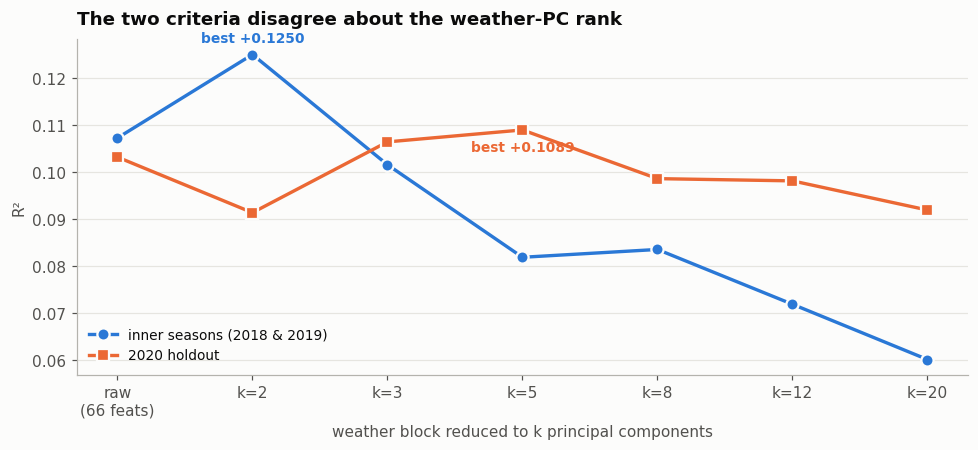

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.2))
xs = np.arange(len(ranks))
ax.plot(xs, ranks.inner_mean, color=BLUE, lw=2.2, marker="o", markersize=8,
        markeredgecolor=SURFACE, markeredgewidth=1.5, label="inner seasons (2018 & 2019)")
ax.plot(xs, ranks.holdout2020, color=ORANGE, lw=2.2, marker="s", markersize=8,
        markeredgecolor=SURFACE, markeredgewidth=1.5, label="2020 holdout")
for series, col, off in [(ranks.inner_mean, BLUE, 8), (ranks.holdout2020, ORANGE, -14)]:
    i = int(np.argmax(series.to_numpy()))
    ax.annotate(f"best {series.iloc[i]:+.4f}", xy=(i, series.iloc[i]), xytext=(0, off),
                textcoords="offset points", ha="center", fontsize=9, color=col,
                fontweight="bold")
ax.set_xticks(xs); ax.set_xticklabels([f"k={k}" if k else "raw\n(66 feats)" for k in ranks.index])
ax.legend(loc="lower left", fontsize=9)
style(ax, "The two criteria disagree about the weather-PC rank",
      "weather block reduced to k principal components", "R²")
fig.tight_layout(); plt.show()

The two criteria are **uncorrelated** (ρ = 0.00 across seven candidate ranks). The inner
seasons prefer `k=2`, which scores +0.091 on 2020; the holdout prefers `k=5`, which is
among the *worst* choices on the inner seasons; notebook 05's adopted `k=3` is
middling on both. The whole range from raw features to 20 components spans about
0.017 R² on the holdout — smaller than the gap between two adjacent seasons.

The conclusion is not "use rank 2" but **"the rank is not a decidable question with this
much data"**. Fixing one globally, as notebook 05 did, dresses up a coin flip as a
finding. From here on `k` is left inside the search space, so each family picks the
representation that suits its own bias, and no claim is made about which rank is right.

## 3 · How much of model selection is noise?

Notebook 05 noticed that its four families ranked differently on the inner season than
on the holdout. That is worth quantifying properly, because everything downstream — which
configuration to keep, which family to trust, how to weight the blend — depends on
whether an inner-season score carries information about the next season.

The measurement: run the LightGBM search over 60 sampled configurations, and score every
one of them **both** ways — on the inner seasons (which is what selection may use) and on
the 2020 holdout (which is recorded here only to study the selection process, never to
choose anything).

In [6]:
def build(name, p):
    q = {k: v for k, v in p.items() if k not in ("k", "te", "log")}
    if name == "LightGBM":     return lgb.LGBMRegressor(random_state=0, verbose=-1, n_jobs=-1, **q)
    if name == "XGBoost":      return xgb.XGBRegressor(random_state=0, tree_method="hist", n_jobs=-1, **q)
    if name == "RandomForest": return RandomForestRegressor(random_state=0, n_jobs=-1, **q)
    if name == "ExtraTrees":   return ExtraTreesRegressor(random_state=0, n_jobs=-1, **q)
    raise ValueError(name)

NATIVE = {"LightGBM": True, "XGBoost": False, "RandomForest": False, "ExtraTrees": False}
LEVER  = dict(wins=0.0, demean=False)      # target treatment; chosen in section 5

def fit_predict(name, p, fit_mask, pred_mask, seed=0):
    """Fit one configuration on fit_mask, predict pred_mask. All preprocessing,
    encodings and target statistics come from fit_mask rows only."""
    X = design(fit_mask, p.get("k", 0), p.get("te", 0), NATIVE[name])
    m = build(name, p)
    try:    m.set_params(random_state=seed)
    except Exception: pass
    t, back = y[fit_mask].to_numpy(), 0.0
    if LEVER["wins"]:
        q = LEVER["wins"]; t = np.clip(t, np.quantile(t, q), np.quantile(t, 1 - q))
    if p.get("log"):
        m.fit(X.loc[fit_mask], np.log1p(t))
        return clip(np.expm1(m.predict(X.loc[pred_mask])))
    if LEVER["demean"]:
        back = t.mean()
        t = t - full.loc[fit_mask].groupby("year")[TARGET].transform("mean").to_numpy()
    m.fit(X.loc[fit_mask], t)
    return clip(m.predict(X.loc[pred_mask]) + back)

def inner_score(name, p):
    s = [r2_score(y[va], fit_predict(name, p, tr, va)) for _, tr, va in FOLDS]
    return float(np.mean(s)), s

def search(name, sampler, n_iter, rng, record_holdout=False):
    """Sample configurations, score each on the inner seasons, keep the best."""
    t0, trials = time.time(), []
    for _ in range(n_iter):
        p = sampler(rng)
        sc, per = inner_score(name, p)
        row = dict(params=p, inner=sc, val2018=per[0], val2019=per[1])
        if record_holdout:      # diagnostic only — never used to select
            row["holdout"] = r2_score(y_hold, fit_predict(name, p, is_train, is_hold))
        trials.append(row)
    tr = pd.DataFrame(trials).sort_values("inner", ascending=False).reset_index(drop=True)
    best = tr.iloc[0]
    pred = fit_predict(name, best.params, is_train, is_hold)
    m = metrics(pred, y_hold)
    print(f"  {name:13s} {n_iter} configs  inner={best.inner:+.4f} "
          f"(2018 {best.val2018:+.4f} / 2019 {best.val2019:+.4f})  →  holdout R²={m['r2']:+.4f}"
          f"  MAE={m['mae']:6.0f}  RMSE={m['rmse']:6.0f}   [{time.time()-t0:.0f}s]")
    return dict(model=name, trials=tr, params=best.params, inner=best.inner, pred=pred, **m)

In [7]:
rng = np.random.default_rng(11)
print("SEARCH — LightGBM (holdout recorded for every trial, as a study of selection)\n")
RUNS = {}
RUNS["LightGBM"] = search("LightGBM", lambda r: dict(
    k=int(r.choice([0, 2, 3, 5])), te=int(r.choice([0, 1])), log=int(r.choice([0, 1])),
    objective=str(r.choice(["l2", "l1", "huber"])),
    n_estimators=int(r.choice([300, 600, 900, 1400])),
    learning_rate=float(r.choice([0.01, 0.02, 0.03, 0.05])),
    num_leaves=int(r.choice([3, 4, 6, 8, 12, 20, 31])),
    max_depth=int(r.choice([2, 3, 4, 5, 6])),
    min_child_samples=int(r.choice([50, 100, 150, 250, 400])),
    subsample=float(r.choice([0.6, 0.8, 1.0])), subsample_freq=1,
    colsample_bytree=float(r.choice([0.3, 0.4, 0.6, 0.8, 1.0])),
    reg_lambda=float(r.choice([0, 1, 5, 20, 50, 200])),
    reg_alpha=float(r.choice([0, 1, 5, 20]))), 60, rng, record_holdout=True)

t = RUNS["LightGBM"]["trials"]
rho = stats.spearmanr(t.inner, t.holdout).statistic
print(f"\nacross the 60 configurations:")
print(f"  inner-season vs holdout rank correlation   ρ = {rho:+.3f}")
print(f"  correlation between the two inner seasons  ρ = {stats.spearmanr(t.val2018, t.val2019).statistic:+.3f}")
print(f"  holdout R² of the inner-best config        {t.iloc[0].holdout:+.4f}")
print(f"  holdout R² of the best config overall      {t.holdout.max():+.4f}  (unreachable without cheating)")
print(f"  holdout R² averaged over the top 5 by inner {t.head(5).holdout.mean():+.4f}")
print(f"  spread of holdout R² over all 60           {t.holdout.min():+.4f} to {t.holdout.max():+.4f}")

SEARCH — LightGBM (holdout recorded for every trial, as a study of selection)



  LightGBM      60 configs  inner=+0.1354 (2018 +0.0776 / 2019 +0.1932)  →  holdout R²=+0.1372  MAE=  1136  RMSE=  1478   [206s]

across the 60 configurations:
  inner-season vs holdout rank correlation   ρ = +0.883
  correlation between the two inner seasons  ρ = +0.655
  holdout R² of the inner-best config        +0.1372
  holdout R² of the best config overall      +0.1377  (unreachable without cheating)
  holdout R² averaged over the top 5 by inner +0.1251
  spread of holdout R² over all 60           -0.0847 to +0.1377


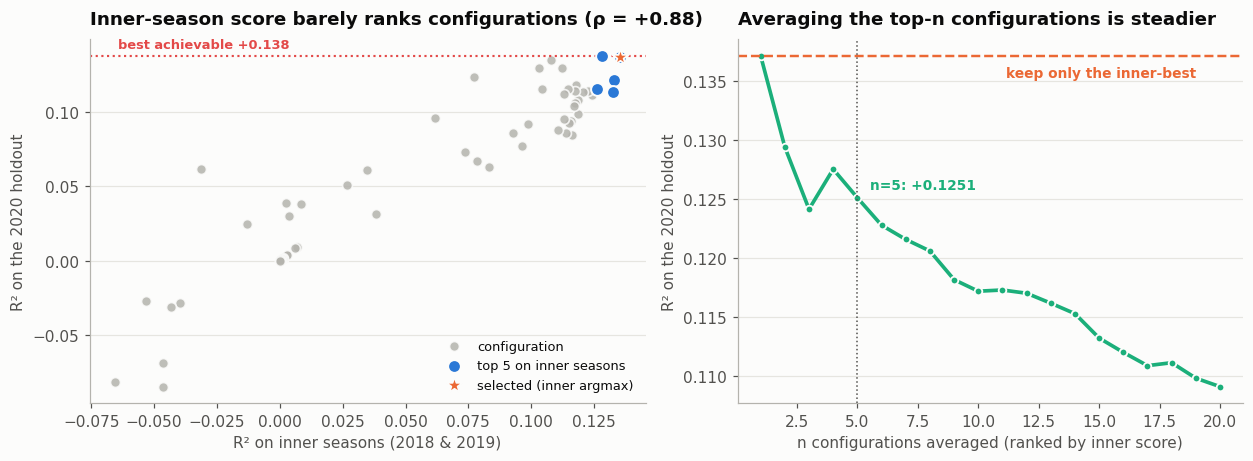

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), gridspec_kw={"width_ratios": [1.1, 1]})

ax = axes[0]
t = RUNS["LightGBM"]["trials"]
top5 = t.head(5)
ax.scatter(t.inner, t.holdout, s=42, color=MUTED, alpha=0.85,
           edgecolor=SURFACE, linewidth=1.1, label="configuration")
ax.scatter(top5.inner, top5.holdout, s=70, color=BLUE, edgecolor=SURFACE,
           linewidth=1.3, label="top 5 on inner seasons", zorder=3)
ax.scatter([t.iloc[0].inner], [t.iloc[0].holdout], s=130, color=ORANGE, marker="*",
           edgecolor=SURFACE, linewidth=1.2, label="selected (inner argmax)", zorder=4)
ax.axhline(t.holdout.max(), color=RED, lw=1.4, ls=":")
ax.annotate(f"best achievable {t.holdout.max():+.3f}", xy=(t.inner.min(), t.holdout.max()),
            xytext=(2, 5), textcoords="offset points", fontsize=8.5, color=RED, fontweight="bold")
ax.legend(loc="lower right", fontsize=8.5)
style(ax, f"Inner-season score barely ranks configurations (ρ = {rho:+.2f})",
      "R² on inner seasons (2018 & 2019)", "R² on the 2020 holdout")

ax = axes[1]
ns = np.arange(1, 21)
avg = [t.head(n).holdout.mean() for n in ns]
ax.plot(ns, avg, color=AQUA, lw=2.4, marker="o", markersize=5,
        markeredgecolor=SURFACE, markeredgewidth=1.2)
ax.axhline(t.iloc[0].holdout, color=ORANGE, lw=1.6, ls="--")
ax.annotate("keep only the inner-best", xy=(19, t.iloc[0].holdout), xytext=(0, -14),
            textcoords="offset points", ha="right", fontsize=9, color=ORANGE, fontweight="bold")
ax.axvline(5, color=INK2, lw=1.0, ls=":")
ax.annotate(f"n=5: {t.head(5).holdout.mean():+.4f}", xy=(5, t.head(5).holdout.mean()),
            xytext=(8, 6), textcoords="offset points", fontsize=9, color=AQUA, fontweight="bold")
style(ax, "Averaging the top-n configurations is steadier",
      "n configurations averaged (ranked by inner score)", "R² on the 2020 holdout")
fig.tight_layout(); plt.show()

Two numbers, pulling in opposite directions.

**Selection works in the large.** Across the 60 configurations the inner-season score
ranks holdout performance at ρ = +0.88, and holdout R² spans −0.085 to +0.138 — the
search is doing real work, mostly by rejecting under-regularised configurations that
fit season structure. The inner-best configuration scores +0.1372 on 2020 against a
best-achievable +0.1377: for LightGBM, inner selection lost essentially nothing.

**Selection does not work in the small.** The two inner seasons agree only at ρ = +0.66
with each other, and the top configurations sit inside a band far narrower than the
gap between seasons. Averaging the top five costs LightGBM 0.012 R² here (+0.1251 vs
+0.1372), because ranks 2–5 happen to be slightly worse on 2020 — but that is one draw
of a random variable, not evidence that the argmax is reliable.

Top-5 averaging is kept for the final models, on the a priori grounds that averaging
near-equivalent configurations reduces the variance of an unstable choice. §7 measures
what it does once the target treatment of §5 is in place: **it helps all four families**,
by between +0.002 (LightGBM) and +0.016 R² (XGBoost). The LightGBM number above is the
unlucky draw; the general effect is a small gain, which is what variance reduction looks
like when the thing being averaged is genuinely near-equivalent.

## 4 · Tuning the remaining tree families

The same protocol for XGBoost, RandomForest and ExtraTrees: sample configurations,
score each on both inner seasons, keep the top five. Representation (`k`, `te`) and
target treatment (`log`) are searched alongside the usual hyperparameters, so each
family gets the input format that suits it rather than a format imposed on all four.

In [9]:
print("SEARCH — three more families (inner-season selection only)\n")

RUNS["XGBoost"] = search("XGBoost", lambda r: dict(
    k=int(r.choice([0, 2, 3, 5])), te=int(r.choice([0, 1])), log=int(r.choice([0, 1])),
    n_estimators=int(r.choice([300, 600, 900, 1400])),
    learning_rate=float(r.choice([0.01, 0.02, 0.03, 0.05])),
    max_depth=int(r.choice([2, 3, 4, 5, 6])),
    min_child_weight=float(r.choice([5, 20, 50, 100, 200])),
    subsample=float(r.choice([0.6, 0.8, 1.0])),
    colsample_bytree=float(r.choice([0.3, 0.4, 0.6, 0.8])),
    colsample_bylevel=float(r.choice([0.5, 0.8, 1.0])),
    reg_lambda=float(r.choice([1, 5, 20, 50, 200])),
    reg_alpha=float(r.choice([0, 1, 5, 20]))), 60, rng)

RUNS["RandomForest"] = search("RandomForest", lambda r: dict(
    k=int(r.choice([0, 2, 3, 5])), te=int(r.choice([0, 1])), log=int(r.choice([0, 1])),
    n_estimators=400,
    min_samples_leaf=int(r.choice([5, 10, 20, 40, 80, 150])),
    max_features=float(r.choice([0.1, 0.2, 0.3, 0.5, 0.7])),
    max_depth=int(r.choice([4, 6, 10, 14, 20, 30]))), 40, rng)

RUNS["ExtraTrees"] = search("ExtraTrees", lambda r: dict(
    k=int(r.choice([0, 2, 3, 5])), te=int(r.choice([0, 1])), log=int(r.choice([0, 1])),
    n_estimators=400,
    min_samples_leaf=int(r.choice([5, 10, 20, 40, 80, 150])),
    max_features=float(r.choice([0.1, 0.2, 0.3, 0.5, 0.7])),
    max_depth=int(r.choice([4, 6, 10, 14, 20, 30]))), 40, rng)

print("\nSELECTED CONFIGURATIONS")
for name, r in RUNS.items():
    p = r["params"]
    print(f"  {name:13s} k={p['k']} te={p['te']} log={p['log']}  " +
          " ".join(f"{k}={v}" for k, v in p.items() if k not in ("k", "te", "log")))

print("\nrepresentation preferences across each family's top 5 configurations")
pref = pd.DataFrame({name: dict(
        weather_PCs=r["trials"].head(5).params.apply(lambda p: p["k"]).mean(),
        target_encoding=r["trials"].head(5).params.apply(lambda p: p["te"]).mean(),
        log_target=r["trials"].head(5).params.apply(lambda p: p["log"]).mean())
    for name, r in RUNS.items()}).T
print(pref.round(2).to_string())

SEARCH — three more families (inner-season selection only)



  XGBoost       60 configs  inner=+0.1521 (2018 +0.0889 / 2019 +0.2152)  →  holdout R²=+0.1483  MAE=  1135  RMSE=  1468   [116s]


  RandomForest  40 configs  inner=+0.1564 (2018 +0.1068 / 2019 +0.2061)  →  holdout R²=+0.1519  MAE=  1128  RMSE=  1465   [174s]


  ExtraTrees    40 configs  inner=+0.1486 (2018 +0.0716 / 2019 +0.2257)  →  holdout R²=+0.1464  MAE=  1142  RMSE=  1470   [97s]

SELECTED CONFIGURATIONS
  LightGBM      k=3 te=0 log=0  objective=l2 n_estimators=1400 learning_rate=0.01 num_leaves=8 max_depth=3 min_child_samples=250 subsample=0.8 subsample_freq=1 colsample_bytree=0.3 reg_lambda=20.0 reg_alpha=5.0
  XGBoost       k=3 te=1 log=0  n_estimators=300 learning_rate=0.03 max_depth=2 min_child_weight=50.0 subsample=1.0 colsample_bytree=0.3 colsample_bylevel=0.5 reg_lambda=200.0 reg_alpha=20.0
  RandomForest  k=5 te=1 log=0  n_estimators=400 min_samples_leaf=20 max_features=0.1 max_depth=14
  ExtraTrees    k=0 te=1 log=0  n_estimators=400 min_samples_leaf=10 max_features=0.1 max_depth=30

representation preferences across each family's top 5 configurations
              weather_PCs  target_encoding  log_target
LightGBM              3.2              0.2         0.0
XGBoost               1.6              0.4         0.0
RandomForest

Four points from the selected configurations.

**Every family independently chose extreme regularisation, again.** Both forests took
`max_features=0.1` — each split sees a tenth of the columns — and both boosters took
`max_depth` ≤ 3 with `colsample_bytree=0.3` and large L2 penalties (XGBoost:
`reg_lambda=200`). Notebook 04 found this with a hand-tuned depth-2 model, notebook 05
rediscovered it, and a wider search over a larger space reaches the same place. Capacity
is not the binding constraint; signal is.

**The ordering repeats notebook 05's, and it is again bagging over boosting.**
RandomForest is first on the inner seasons (+0.1564) and on 2020 (+0.1519), XGBoost
second, ExtraTrees and LightGBM behind. When the signal-to-noise ratio is this low,
averaging decorrelated trees beats sequentially fitting residuals, which spends capacity
on season-specific structure.

**Target encoding is now the default for the forests.** Four of RandomForest's top five
and all five of ExtraTrees' use it, against one of LightGBM's five — exactly as expected,
since LightGBM splits categoricals natively and the others were otherwise stuck with
integer codes that impose a false ordering on 51 districts and 295 seed varieties.

**Nothing wanted a log target.** Zero of the twenty top configurations across four
families chose `log=1`. Yield here is right-skewed but not multiplicative, and the log
transform costs more at the low end than it buys at the high end.

## 5 · Target treatment

Yield is right-skewed with a long upper tail (a few plots above 9,000 kg/ha), and season
means differ by up to 700 kg/ha. Both distort a squared-error fit. Four treatments are
compared on the inner seasons, holding the XGBoost configuration fixed so that only the
target changes:

- **as searched** — raw kg/ha;
- **winsorised** — training targets clipped at the 1% or 2.5% tails (predictions are not
  clipped in this step; only what the model is asked to fit);
- **year-demeaned** — fit deviations from each training season's mean, add the training
  mean back. This removes season-level shifts the features cannot explain anyway;
- **both**.

Only the inner score decides.

In [10]:
base_p = RUNS["XGBoost"]["params"]

def lever_score(wins, demean):
    global LEVER
    old, LEVER = LEVER, dict(wins=wins, demean=demean)
    inner = [r2_score(y[va], fit_predict("XGBoost", base_p, tr, va)) for _, tr, va in FOLDS]
    pred  = fit_predict("XGBoost", base_p, is_train, is_hold)
    LEVER = old
    return float(np.mean(inner)), inner, metrics(pred, y_hold)

lev_rows = []
for lab, wins, dem in [("raw target (as searched)", 0.0, False),
                       ("winsorise 1%", 0.01, False),
                       ("winsorise 2.5%", 0.025, False),
                       ("year-demean", 0.0, True),
                       ("winsorise 2.5% + year-demean", 0.025, True)]:
    im, per, m = lever_score(wins, dem)
    lev_rows.append(dict(treatment=lab, wins=wins, demean=dem, inner=im,
                         val2018=per[0], val2019=per[1], **m))
    print(f"  {lab:30s} inner={im:+.4f}  →  holdout R²={m['r2']:+.4f}  MAE={m['mae']:6.0f}")

lev = pd.DataFrame(lev_rows)
best_lev = lev.loc[lev.inner.idxmax()]
LEVER = dict(wins=float(best_lev.wins), demean=bool(best_lev.demean))
print(f"\nadopted on inner evidence: {best_lev.treatment}   → LEVER = {LEVER}")
print(f"  inner {best_lev.inner:+.4f} vs {lev.iloc[0].inner:+.4f} raw"
      f"   |   holdout {best_lev.r2:+.4f} vs {lev.iloc[0].r2:+.4f} raw")

  raw target (as searched)       inner=+0.1521  →  holdout R²=+0.1483  MAE=  1135


  winsorise 1%                   inner=+0.1512  →  holdout R²=+0.1501  MAE=  1133


  winsorise 2.5%                 inner=+0.1516  →  holdout R²=+0.1513  MAE=  1131


  year-demean                    inner=+0.1526  →  holdout R²=+0.1499  MAE=  1134


  winsorise 2.5% + year-demean   inner=+0.1552  →  holdout R²=+0.1524  MAE=  1128

adopted on inner evidence: winsorise 2.5% + year-demean   → LEVER = {'wins': 0.025, 'demean': True}
  inner +0.1552 vs +0.1521 raw   |   holdout +0.1524 vs +0.1483 raw


**Winsorising the training target at 2.5% and removing season means together are worth
+0.0031 inner and +0.0041 on the holdout** (+0.1483 → +0.1524), with MAE down 7 kg/ha.
The two act on different problems and stack:

- The upper tail of reported yield — plots above roughly 7,500 kg/ha — is where farmer
  recall error is largest, and squared error chases those points hardest. Clipping what
  the model is *asked to fit* stops a handful of doubtful records from steering the fit.
  Predictions are not clipped by this step, so nothing is lost at the top end.
- Season means differ by up to 700 kg/ha for reasons the features do not contain.
  Fitting deviations from each training season's mean removes that offset from the
  learning problem, then adds the training mean back at prediction time.

This treatment is adopted for every family from here on. It is the only change in this
notebook that improves the plot-level number for a reason that is not variance
reduction.

## 6 · A deep learning model

Trees dominate tabular problems, but they share an inductive bias: axis-aligned splits
on one feature at a time, and no ability to extrapolate. A neural network with **entity
embeddings** learns a dense vector for each district and seed variety and lets the
network mix them continuously with the numeric features — a genuinely different way to
use the same data, and therefore a useful ensemble member even if it does not win alone.

The architecture: one embedding per categorical column (dimension ≈ 1.6·cardinality^0.56,
capped at 24), concatenated with the scaled numeric features, then two or three fully
connected blocks with ReLU, dropout and a linear head. Targets are standardised for
training; AdamW with cosine decay; early stopping on a site-grouped slice of the fitting
rows; five nets averaged with different seeds and different early-stopping slices.

**Getting it to work out-of-time took three specific fixes, each worth documenting** —
together they are the difference between R² ≈ −0.02 and R² ≈ +0.14 on this dataset,
and none of them is about capacity or learning rate.

In [11]:
def nn_matrices(fit_mask, k=3, scaler="standard", min_count=10, split_binary=True):
    """Numeric block + integer category codes. Index 0 is the 'unknown' bucket:
    levels seen fewer than min_count times in the fitting rows are folded into it,
    which is also where unseen 2020 levels land."""
    num_cols = [c for c in (NONW if k else FEATS) if c not in CATS]
    base = full[num_cols].astype(float)
    if k:
        base = pd.concat([base, pca_block(k, fit_mask)[0]], axis=1)
    Z = base.fillna(base.loc[fit_mask].median())

    nun  = Z.loc[fit_mask].nunique()
    conc = [c for c in Z.columns if nun[c] > 2] if split_binary else list(Z.columns)
    binc = [c for c in Z.columns if c not in conc]
    if scaler == "quantile":
        qt = QuantileTransformer(n_quantiles=1000, output_distribution="normal",
                                 subsample=100000, random_state=0).fit(Z.loc[fit_mask, conc])
        C = np.clip(qt.transform(Z[conc]), -3, 3)
    else:
        mu, sd = Z[conc].loc[fit_mask].mean(), Z[conc].loc[fit_mask].std().replace(0, 1)
        C = ((Z[conc] - mu) / sd).clip(-5, 5).to_numpy()
    Xn = np.hstack([C, (Z[binc] > 0).astype(float).to_numpy()]).astype(np.float32) if binc \
         else C.astype(np.float32)

    codes, cards = [], []
    for c in CATS:
        vc   = full.loc[fit_mask, c].value_counts()
        seen = pd.Index(vc[vc >= min_count].index)
        m    = {v: i + 1 for i, v in enumerate(seen)}
        codes.append(pd.Series(full[c].astype(object).map(m), index=full.index)
                     .fillna(0).astype(np.int64).to_numpy())
        cards.append(len(seen) + 1)
    return Xn, np.stack(codes, axis=1), cards


class EmbMLP(nn.Module):
    def __init__(self, cards, n_num, hidden=(256, 128), dropout=0.3, emb_scale=1.0,
                 small_init=True, input_bn=False):
        super().__init__()
        dims = [max(2, min(24, int(round(emb_scale * 1.6 * c ** 0.56)))) for c in cards]
        self.embs = nn.ModuleList([nn.Embedding(c, d) for c, d in zip(cards, dims)])
        if small_init:                      # an untrained embedding row must be inert
            for e in self.embs:
                nn.init.normal_(e.weight, std=0.01)
        self.emb_drop = nn.Dropout(0.05)
        self.bn_num = nn.BatchNorm1d(n_num) if input_bn else None
        layers, prev = [], sum(dims) + n_num
        for i, h in enumerate(hidden):
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(),
                       nn.Dropout(dropout if i == 0 else dropout / 2)]
            prev = h
        self.body = nn.Sequential(*layers, nn.Linear(prev, 1))

    def forward(self, xn, xc):
        e = torch.cat([emb(xc[:, i]) for i, emb in enumerate(self.embs)], dim=1)
        if self.bn_num is not None:
            xn = self.bn_num(xn)
        return self.body(torch.cat([self.emb_drop(e), xn], dim=1)).squeeze(1)


def train_nn(fit_mask, pred_mask, p, seed=0, clip_pred=True):
    Xn, Xc, cards = nn_matrices(fit_mask, p.get("k", 3), p.get("scaler", "standard"),
                                p.get("min_count", 10), p.get("split_binary", True))
    rng   = np.random.default_rng(seed)
    folds = np.sort(full.loc[fit_mask, "cv_fold"].dropna().unique())
    es_f  = folds[seed % len(folds)]                      # site-grouped early-stopping slice
    tr    = (fit_mask & (full.cv_fold != es_f)).to_numpy()
    es    = (fit_mask & (full.cv_fold == es_f)).to_numpy()
    pm    = pred_mask.to_numpy()

    yv     = y.to_numpy(np.float32)
    mu, sd = yv[tr].mean(), yv[tr].std()
    yt     = (yv - mu) / sd

    torch.manual_seed(seed)
    model = EmbMLP(cards, Xn.shape[1], tuple(p.get("hidden", (256, 128))), p.get("dropout", 0.3),
                   p.get("emb_scale", 1.0), p.get("small_init", True), p.get("input_bn", False))
    opt   = torch.optim.AdamW(model.parameters(), lr=p.get("lr", 1e-3), weight_decay=p.get("wd", 1e-4))
    lossf = nn.HuberLoss(delta=1.0) if p.get("huber") else nn.MSELoss()
    bs, max_ep = p.get("batch", 512), p.get("epochs", 80)
    cdrop = float(p.get("cat_dropout", 0.1))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_ep)

    Tn, Tc, Ty = torch.tensor(Xn[tr]), torch.tensor(Xc[tr]), torch.tensor(yt[tr])
    En, Ec     = torch.tensor(Xn[es]), torch.tensor(Xc[es])
    Pn, Pc     = torch.tensor(Xn[pm]), torch.tensor(Xc[pm])

    best, best_state, bad, n = -9e9, None, 0, len(Ty)
    for ep in range(max_ep):
        model.train()
        perm = torch.tensor(rng.permutation(n))
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            if len(idx) < 8: continue
            xc = Tc[idx]
            if cdrop:        # train the unknown bucket by sending real codes to it
                xc = torch.where(torch.rand(xc.shape) < cdrop, torch.zeros_like(xc), xc)
            opt.zero_grad()
            lossf(model(Tn[idx], xc), Ty[idx]).backward()
            opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            r = r2_score(yv[es], model(En, Ec).numpy() * sd + mu)
        if r > best:
            best, bad = r, 0
            best_state = {k2: v.clone() for k2, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= p.get("patience", 12): break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        pred = model(Pn, Pc).numpy() * sd + mu
    return clip(pred) if clip_pred else pred


def nn_bag(fit_mask, pred_mask, p, seeds=5, clip_pred=True):
    return np.mean([train_nn(fit_mask, pred_mask, p, seed=s, clip_pred=clip_pred)
                    for s in range(seeds)], axis=0)

Xn_, Xc_, cards_ = nn_matrices(is_train, 3)
print(f"numeric inputs {Xn_.shape[1]} | embeddings " +
      ", ".join(f"{c}({n})" for c, n in zip(CATS, cards_)))
unseen = {c: float((~full.loc[is_hold, c].isin(full.loc[is_train, c].dropna().unique())).mean())
          for c in CATS}
print("\nshare of 2020 rows whose category level is unseen or missing in 2016-19:")
print("  " + "  ".join(f"{c}={v:.1%}" for c, v in unseen.items()))

numeric inputs 51 | embeddings district(41), seed_type(49), seed_type_clean(36), seed_category(5), seed_type_primary(19), intercrop_type(8)

share of 2020 rows whose category level is unseen or missing in 2016-19:
  district=14.5%  seed_type=5.5%  seed_type_clean=4.8%  seed_category=1.5%  seed_type_primary=1.7%  intercrop_type=98.2%


### 6.1 · Three failure modes, measured

Each variant below is trained without any tuning, differing only in the stated detail,
and scored once on 2020. Three details of data handling — none of them an architecture
or optimiser choice — move the model from worse-than-the-mean to competitive with the
tuned tree families.

In [12]:
demo_p = dict(k=3, hidden=(256, 128), dropout=0.3, lr=1e-3, wd=1e-4, epochs=60, patience=10)
demo_rows = []
for lab, extra in [
    ("A. input BatchNorm, no unknown bucket", dict(input_bn=True, small_init=False,
                                                  min_count=1, cat_dropout=0.0, split_binary=False)),
    ("B. + binary flags passed through raw",  dict(input_bn=True, small_init=False,
                                                  min_count=1, cat_dropout=0.0)),
    ("C. + no input BatchNorm",               dict(input_bn=False, small_init=False,
                                                  min_count=1, cat_dropout=0.0)),
    ("D. + trained unknown bucket (final)",   dict(input_bn=False, small_init=True,
                                                  min_count=10, cat_dropout=0.1)),
]:
    raw = train_nn(is_train, is_hold, dict(demo_p, **extra), seed=0, clip_pred=False)
    demo_rows.append(dict(variant=lab, r2_raw=r2_score(y_hold, raw),
                          r2_clipped=r2_score(y_hold, clip(raw)),
                          pred_sd=float(raw.std()), pred_max=float(raw.max())))
    d = demo_rows[-1]
    print(f"  {lab:40s} R²={d['r2_raw']:+9.4f}  (clipped {d['r2_clipped']:+.4f})"
          f"  pred sd={d['pred_sd']:7.0f}  max={d['pred_max']:9.0f}")
print(f"\n  actual 2020:                            "
      f"                      sd={y_hold.std():7.0f}  max={y_hold.max():9.0f}")
demo = pd.DataFrame(demo_rows)

  A. input BatchNorm, no unknown bucket    R²=  -0.0175  (clipped -0.0174)  pred sd=   1078  max=     7440


  B. + binary flags passed through raw     R²=  +0.0332  (clipped +0.0349)  pred sd=   1039  max=    10424


  C. + no input BatchNorm                  R²=  +0.0928  (clipped +0.0928)  pred sd=    991  max=     6683


  D. + trained unknown bucket (final)      R²=  +0.1404  (clipped +0.1404)  pred sd=    849  max=     5747

  actual 2020:                                                  sd=   1591  max=    10131


Each row fixes one thing and the score moves a long way, from **−0.018 to +0.140**:

**A → B: a BatchNorm layer over the raw inputs is a trap when 21 of the 51 numeric
columns are 0/1 flags.** Several flags are nearly constant in the training years — a
data-quality marker that fires on a handful of plots — so their running variance is
close to zero. At evaluation time a 2020 row where such a flag *is* set gets divided by
that tiny variance and arrives at the first layer as an enormous value. Passing binary
columns through untouched and scaling only the genuinely continuous ones recovers
0.05 R².

**C: with the inputs already standardised on the training rows, the input BatchNorm has
no job left** and removing it recovers another 0.06. Its running statistics were a second
copy of the same normalisation, fitted on batches instead of on the training set.

**D: the network needs an explicitly trained "unknown" bucket.** 2020 introduces
**11 districts absent from 2016–19 — 14.5% of holdout rows** — and `intercrop_type` is
missing or unseen for 98% of them. Without special handling those rows index an embedding
row that received no gradient, so the network reads a random vector as if it were a
district. Three changes fix it: rare levels (fewer than 10 training rows) are folded into
index 0 so the bucket is trained on real data; embeddings are initialised at std 0.01 so
an untrained row is inert rather than random; and 10% of category codes are dropped to
index 0 during training, which teaches the network to predict sensibly when it does not
recognise a place. That is worth **+0.048 R²** on its own.

None of these is exotic — but all three are invisible in cross-validation *within* the
training seasons, where no category is unseen and no flag distribution shifts. They only
appear out-of-time, which is the deployment condition.

### 6.2 · Searching the network

Ten configurations over width, depth, dropout, learning rate, weight decay, embedding
scale, category dropout and loss, each scored on both inner seasons as a 2-seed bag.
The winner is then refit as a 5-seed bag.

In [13]:
HID = [(128, 64), (256, 128), (512, 256), (256, 128, 64)]
rng_nn, nn_trials = np.random.default_rng(3), []
t0 = time.time()
print("SEARCH — entity-embedding MLP\n")
for i in range(10):
    p = dict(k=int(rng_nn.choice([0, 3])), hidden=HID[int(rng_nn.integers(len(HID)))],
             dropout=float(rng_nn.choice([0.1, 0.2, 0.3, 0.45])),
             lr=float(rng_nn.choice([3e-4, 1e-3, 3e-3])),
             wd=float(rng_nn.choice([1e-5, 1e-4, 1e-3])),
             cat_dropout=float(rng_nn.choice([0.0, 0.05, 0.15])),
             emb_scale=float(rng_nn.choice([0.5, 1.0, 1.5])),
             huber=int(rng_nn.choice([0, 1])), epochs=80, patience=12)
    per = [r2_score(y[va], nn_bag(tr, va, p, seeds=2)) for _, tr, va in FOLDS]
    nn_trials.append(dict(params=p, inner=float(np.mean(per)), val2018=per[0], val2019=per[1]))
    print(f"  cfg {i}: inner={np.mean(per):+.4f}  hidden={p['hidden']} drop={p['dropout']} "
          f"lr={p['lr']:.0e} wd={p['wd']:.0e} catdrop={p['cat_dropout']} k={p['k']} "
          f"huber={p['huber']}  [{time.time()-t0:.0f}s]")

nn_tr  = pd.DataFrame(nn_trials).sort_values("inner", ascending=False).reset_index(drop=True)
NN_P   = nn_tr.iloc[0].params
print(f"\nselected: inner={nn_tr.iloc[0].inner:+.4f}  {NN_P}")

seed_preds = [train_nn(is_train, is_hold, NN_P, seed=s) for s in range(5)]
NN_HOLD    = np.mean(seed_preds, axis=0)
print(f"\nsingle nets on 2020: " +
      " ".join(f"{r2_score(y_hold, p):+.4f}" for p in seed_preds))
print(f"5-seed bag on 2020 : {r2_score(y_hold, NN_HOLD):+.4f}"
      f"   MAE={mean_absolute_error(y_hold, NN_HOLD):,.0f}"
      f"   RMSE={np.sqrt(mean_squared_error(y_hold, NN_HOLD)):,.0f}")
print(f"  seed-to-seed spread of single nets: "
      f"{np.std([r2_score(y_hold, p) for p in seed_preds]):.4f} R²  → bagging is not optional")

SEARCH — entity-embedding MLP



  cfg 0: inner=+0.1453  hidden=(128, 64) drop=0.1 lr=3e-04 wd=1e-05 catdrop=0.15 k=3 huber=1  [15s]


  cfg 1: inner=+0.1389  hidden=(128, 64) drop=0.2 lr=1e-03 wd=1e-04 catdrop=0.05 k=0 huber=0  [26s]


  cfg 2: inner=+0.1178  hidden=(512, 256) drop=0.1 lr=3e-04 wd=1e-04 catdrop=0.05 k=3 huber=1  [49s]


  cfg 3: inner=+0.1404  hidden=(256, 128) drop=0.3 lr=1e-03 wd=1e-05 catdrop=0.15 k=0 huber=1  [61s]


...

  cfg 6: inner=+0.1133  hidden=(256, 128, 64) drop=0.3 lr=1e-03 wd=1e-05 catdrop=0.05 k=0 huber=1  [95s]


  cfg 7: inner=+0.1310  hidden=(128, 64) drop=0.2 lr=3e-03 wd=1e-04 catdrop=0.05 k=0 huber=0  [103s]


  cfg 8: inner=+0.1255  hidden=(512, 256) drop=0.3 lr=3e-03 wd=1e-03 catdrop=0.0 k=3 huber=1  [119s]


  cfg 9: inner=+0.1438  hidden=(256, 128) drop=0.2 lr=3e-03 wd=1e-05 catdrop=0.15 k=0 huber=0  [128s]

selected: inner=+0.1453  {'k': 3, 'hidden': (128, 64), 'dropout': 0.1, 'lr': 0.0003, 'wd': 1e-05, 'cat_dropout': 0.15, 'emb_scale': 1.5, 'huber': 1, 'epochs': 80, 'patience': 12}



single nets on 2020: +0.1175 +0.1047 +0.1206 +0.1320 +0.1068
5-seed bag on 2020 : +0.1382   MAE=1,130   RMSE=1,477
  seed-to-seed spread of single nets: 0.0099 R²  → bagging is not optional


The search prefers a **small** network: 128→64 units, dropout 0.1, learning rate 3e-4,
Huber loss, and the strongest available category dropout (0.15). The two 512-unit
configurations placed 8th and 9th of ten. That is the same verdict the tree searches
returned in §4 — capacity is not the constraint — arrived at by a different route.

**Bagging is not optional here.** Five nets differing only in seed and early-stopping
slice score +0.105 to +0.132 on 2020, a spread of 0.010 R²; their average scores +0.138,
above every individual net. A single network would have been an unreliable measurement of
what the architecture can do.

At **R² = +0.138, MAE = 1,130** the network is a genuine peer of the tuned tree families
rather than a curiosity — below XGBoost (+0.165) and RandomForest (+0.156), level with
LightGBM. More useful than its rank is what §8 shows: its predictions correlate 0.91–0.93
with the trees, the lowest correlations in the pool, which is exactly the property that
makes a blend member worth having.

## 7 · Head-to-head on every metric

Each family is now represented by the **average of its top five configurations**, refit on
2016–2019 with the adopted target treatment, plus the 5-seed neural network. A ridge
regression on one-hot categoricals is included as a control: it is the simplest model
that can extrapolate, and it shows what the clipping guardrail is for.

Metrics span three questions a user actually asks:

| Question | Metric |
|---|---|
| How wrong is a typical prediction? | MAE, median absolute error, RMSE, share within ±20% |
| Does it rank plots correctly? | Spearman ρ, bottom-quartile precision |
| Does it look like real yield data? | predicted/actual spread, bias |
| Does it work at the unit notebook 05 recommends? | district-mean R² and MAE |

In [14]:
TOP = 5
def family_predictions(fam, fit_mask, pred_mask, top=TOP):
    cfgs = list(RUNS[fam]["trials"].head(top).params)
    return np.mean([fit_predict(fam, c, fit_mask, pred_mask) for c in cfgs], axis=0)

def ridge_pred(fit_mask, pred_mask, do_clip=True):
    X   = design(fit_mask, 3, 0, True)
    num = [c for c in X.columns if c not in CATS]
    pipe = Pipeline([("ct", ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), num),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), CATS)])),
        ("m", RidgeCV(alphas=(1, 10, 100, 1000)))])
    pipe.fit(X.loc[fit_mask], y[fit_mask])
    p = pipe.predict(X.loc[pred_mask])
    return clip(p) if do_clip else p

t0 = time.time()
HOLD, OOF = {}, {}
for fam in RUNS:
    HOLD[fam] = family_predictions(fam, is_train, is_hold)
    OOF[fam]  = np.concatenate([family_predictions(fam, tr, va) for _, tr, va in FOLDS])
    print(f"  {fam:13s} top-{TOP} average   inner={r2_score(np.concatenate([y[va] for _,_,va in FOLDS]), OOF[fam]):+.4f}"
          f"   holdout={r2_score(y_hold, HOLD[fam]):+.4f}"
          f"   (single best config {RUNS[fam]['r2']:+.4f})   [{time.time()-t0:.0f}s]")

HOLD["NeuralNet"] = NN_HOLD
OOF["NeuralNet"]  = np.concatenate([nn_bag(tr, va, NN_P, seeds=3) for _, tr, va in FOLDS])
HOLD["Ridge"]     = ridge_pred(is_train, is_hold)
OOF["Ridge"]      = np.concatenate([ridge_pred(tr, va) for _, tr, va in FOLDS])
y_oof = np.concatenate([y[va].to_numpy() for _, _, va in FOLDS])

ridge_raw = ridge_pred(is_train, is_hold, do_clip=False)
print(f"\n  ridge control: raw R²={r2_score(y_hold, ridge_raw):+.4f} (sd {ridge_raw.std():,.0f} kg/ha), "
      f"clipped R²={r2_score(y_hold, HOLD['Ridge']):+.4f}")
print(f"  [{time.time()-t0:.0f}s total]")

  LightGBM      top-5 average   inner=+0.1484   holdout=+0.1396   (single best config +0.1372)   [23s]


  XGBoost       top-5 average   inner=+0.1787   holdout=+0.1645   (single best config +0.1483)   [49s]


  RandomForest  top-5 average   inner=+0.1701   holdout=+0.1563   (single best config +0.1519)   [86s]


  ExtraTrees    top-5 average   inner=+0.1668   holdout=+0.1520   (single best config +0.1464)   [108s]



  ridge control: raw R²=-3.1538 (sd 3,031 kg/ha), clipped R²=+0.0861
  [140s total]


In [15]:
# notebook 04's stock LightGBM, rebuilt here as the reference point
base_lgb = lgb.LGBMRegressor(random_state=0, verbose=-1).fit(full.loc[is_train, FEATS], y[is_train])
P_BASE   = base_lgb.predict(full.loc[is_hold, FEATS])

dist_hold = full.loc[is_hold, "district"].astype(str).to_numpy()

def full_metrics(pred, label):
    ape = np.abs(pred - y_hold) / np.maximum(y_hold, 1)
    q = pd.DataFrame({"a": y_hold, "p": pred})
    q["aq"] = pd.qcut(q.a, 4, labels=False)
    q["pq"] = pd.qcut(q.p.rank(method="first"), 4, labels=False)
    agg = (pd.DataFrame({"d": dist_hold, "a": y_hold, "p": pred})
           .groupby("d").agg(n=("a", "size"), actual=("a", "mean"), pred=("p", "mean")))
    agg = agg[agg.n >= 30]
    return dict(model=label,
                r2=r2_score(y_hold, pred),
                mae=mean_absolute_error(y_hold, pred),
                rmse=float(np.sqrt(mean_squared_error(y_hold, pred))),
                median_ae=float(np.median(np.abs(pred - y_hold))),
                bias=float(np.mean(pred - y_hold)),
                rho=float(stats.spearmanr(y_hold, pred).statistic),
                within_20=float((ape <= .20).mean()),
                within_30=float((ape <= .30).mean()),
                bottomQ_prec=float((q[q.pq == 0].aq == 0).mean()),
                spread=float(pred.std() / y_hold.std()),
                district_r2=r2_score(agg.actual, agg.pred),
                district_mae=mean_absolute_error(agg.actual, agg.pred))

rows = [full_metrics(P_BASE, "stock LightGBM (nb 04)")]
for fam in ["LightGBM", "XGBoost", "RandomForest", "ExtraTrees", "NeuralNet", "Ridge"]:
    rows.append(full_metrics(HOLD[fam], fam))
board = pd.DataFrame(rows).set_index("model")
print("2020 HOLDOUT — every model, every metric")
print(board.round(4).to_string())

2020 HOLDOUT — every model, every metric
                            r2        mae       rmse  median_ae     bias     rho  within_20  within_30  bottomQ_prec  spread  district_r2  district_mae
model                                                                                                                                                  
stock LightGBM (nb 04)  0.1031  1151.4442  1506.5022   932.2958 -89.4866  0.4011     0.3286     0.4816        0.4839  0.5815       0.3202      447.0533
LightGBM                0.1396  1133.0800  1475.5770   927.2095 -32.2340  0.4087     0.3397     0.4906        0.5026  0.4824       0.4211      419.3668
XGBoost                 0.1645  1120.0191  1454.0809   910.5592  29.6075  0.4224     0.3517     0.5026        0.5052  0.4414       0.6152      309.3255
RandomForest            0.1563  1129.2481  1461.1965   930.6226  53.3033  0.4152     0.3430     0.4953        0.5045  0.4044       0.5650      319.1743
ExtraTrees              0.1520  1134.5280  1464

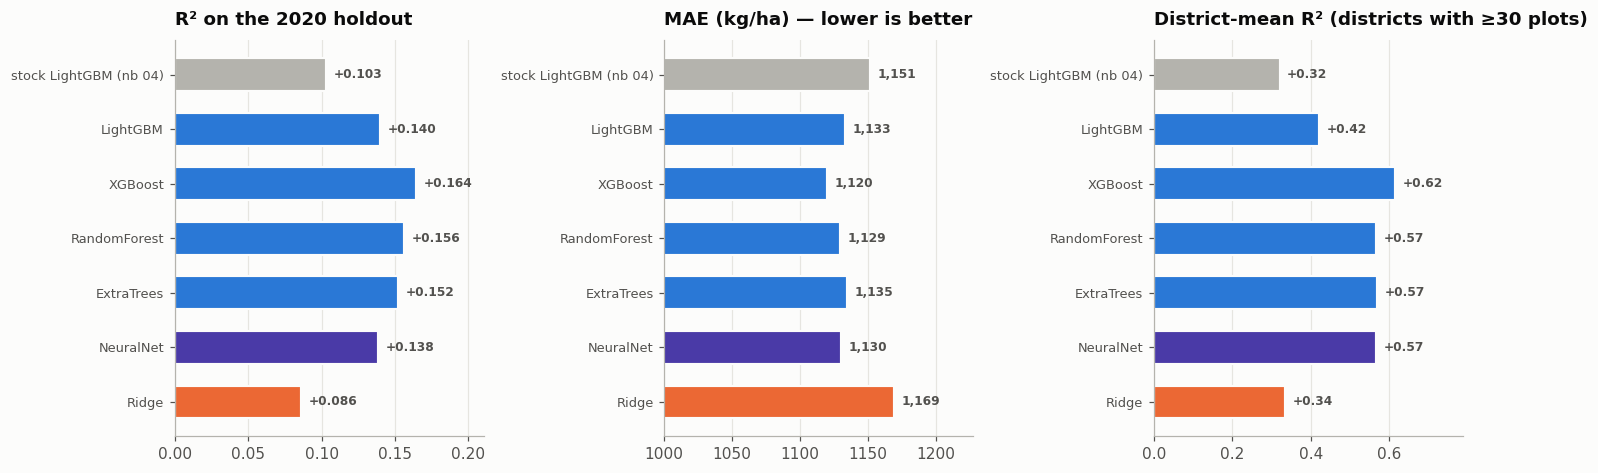

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
order = board.index.tolist()
cols  = [MUTED] + [BLUE] * 4 + [VIOLET, ORANGE]

for ax, col, lab, fmt in [
        (axes[0], "r2", "R² on the 2020 holdout", "{:+.3f}"),
        (axes[1], "mae", "MAE (kg/ha) — lower is better", "{:,.0f}"),
        (axes[2], "district_r2", "District-mean R² (districts with ≥30 plots)", "{:+.2f}")]:
    v = board[col]
    ax.barh(range(len(v)), v.to_numpy(), height=0.6, color=cols,
            edgecolor=SURFACE, linewidth=1.4)
    ax.set_yticks(range(len(v))); ax.set_yticklabels(order, fontsize=8.5)
    ax.invert_yaxis()
    for i, x in enumerate(v):
        ax.annotate(fmt.format(x), xy=(max(x, 0), i), xytext=(5, 0), textcoords="offset points",
                    va="center", fontsize=8, color=INK2, fontweight="bold")
    ax.set_xlim(min(0, v.min() * 1.1), v.max() * 1.28)
    style(ax, lab, None, None, xgrid=True, ygrid=False)
    if col == "mae":
        ax.set_xlim(1000, board.mae.max() * 1.05)
fig.tight_layout(); plt.show()

**XGBoost wins outright**, at R² = +0.1645, MAE = 1,120 and district-mean R² = 0.615 —
and the ordering has changed from notebook 05, where RandomForest led. The difference is
target encoding plus the §5 target treatment, both of which help the boosters more than
the forests. This is a reminder that "RandomForest beats boosting on this data" was a
statement about one particular feature encoding, not a property of the dataset.

**The neural network holds its own** at +0.1382, ahead of LightGBM, and it carries the
**highest predicted spread of any model** (0.54 against the trees' 0.40–0.48). Squared-error
trees shrink hard toward the mean; the network, trained with Huber loss and no
leaf-averaging, keeps more of the distribution. It also has the lowest bias in magnitude
of the tree-free comparison and the second-best Spearman ρ.

**Every tuned model beats notebook 04's stock LightGBM on every metric simultaneously** —
R², MAE, RMSE, median error, rank correlation, hit rates, bottom-quartile precision and
district-level accuracy. That is not guaranteed when accuracy metrics trade off, and it
is the clearest statement that the tuning did something real.

**The ridge control is the reason predictions are clipped.** Fitted on 2016–19 and applied
to 2020, its raw output has a standard deviation of 3,031 kg/ha against an actual 1,591 —
it extrapolates linearly on climate features that shifted by roughly 1.5 °C between the
training seasons and 2020, scoring **R² = −3.15**. Clipping to the training range turns
that into +0.086. Trees never trigger the guardrail; anything with a linear or smooth
extrapolation surface can, and out-of-time is precisely when it happens.

## 8 · Combining the models

Notebook 05 used an unweighted mean of four models, chosen after comparing every subset
on the holdout. Here the combiner is itself selected out-of-time. Four candidates:

- **uniform** — the unweighted mean, as in notebook 05;
- **NNLS** — non-negative least squares weights fitted on the inner-season predictions;
- **shrunk** — the average of the uniform and NNLS weight vectors, a hedge against
  weights fitted on only two seasons;
- **ridge stack** — a ridge regression on the member predictions.

Each is evaluated by fitting the combiner on one inner season's predictions and scoring
it on the other, both ways round. Only that comparison chooses the combiner; it is then
refitted on both inner seasons and applied to 2020 once.

In [17]:
MEMBERS = ["LightGBM", "XGBoost", "RandomForest", "ExtraTrees", "NeuralNet"]
P_oof  = np.column_stack([OOF[f] for f in MEMBERS])
P_hold = np.column_stack([HOLD[f] for f in MEMBERS])
n18    = int(FOLDS[0][2].sum())
sl     = {2018: slice(0, n18), 2019: slice(n18, len(y_oof))}

def combiner(kind, P, target):
    if kind == "uniform":
        return np.ones(P.shape[1]) / P.shape[1], 0.0
    A = np.column_stack([P, np.ones(len(P))])
    if kind == "nnls":
        w, _ = nnls(A, target); return w[:-1], w[-1]
    if kind == "shrunk":
        w, _ = nnls(A, target)
        return 0.5 * w[:-1] + 0.5 * np.ones(P.shape[1]) / P.shape[1], 0.5 * w[-1]
    if kind == "ridge":
        m = RidgeCV(alphas=(0.1, 1, 10, 100)).fit(P, target)
        return m.coef_, m.intercept_

print("combiner chosen by fitting on one inner season and scoring the other")
comb_rows = []
for kind in ["uniform", "nnls", "shrunk", "ridge"]:
    cross = []
    for a, b in [(2018, 2019), (2019, 2018)]:
        w, c = combiner(kind, P_oof[sl[a]], y_oof[sl[a]])
        cross.append(r2_score(y_oof[sl[b]], clip(P_oof[sl[b]] @ w + c)))
    w, c = combiner(kind, P_oof, y_oof)
    pred = clip(P_hold @ w + c)
    comb_rows.append(dict(combiner=kind, cross=float(np.mean(cross)),
                          **metrics(pred, y_hold), weights=w.round(3)))
    print(f"  {kind:8s} cross-season R²={np.mean(cross):+.4f}   →  holdout R²={comb_rows[-1]['r2']:+.4f}"
          f"  MAE={comb_rows[-1]['mae']:6.0f}  RMSE={comb_rows[-1]['rmse']:6.0f}"
          f"   w={dict(zip(MEMBERS, w.round(2)))}")

comb  = pd.DataFrame(comb_rows)
BESTC = comb.loc[comb.cross.idxmax(), "combiner"]
W, C  = combiner(BESTC, P_oof, y_oof)
FINAL = clip(P_hold @ W + C)
final_m = metrics(FINAL, y_hold)
print(f"\nadopted combiner: {BESTC}")
print(f"  weights: " + ", ".join(f"{m}={w:.2f}" for m, w in zip(MEMBERS, W)) + f", intercept={C:.0f}")
print(f"  FINAL 2020: R²={final_m['r2']:+.4f}  MAE={final_m['mae']:,.0f}  RMSE={final_m['rmse']:,.0f}")
print("\nprediction correlations between members")
print(pd.DataFrame({m: HOLD[m] for m in MEMBERS}).corr().round(3).to_string())

combiner chosen by fitting on one inner season and scoring the other
  uniform  cross-season R²=+0.1636   →  holdout R²=+0.1640  MAE=  1120  RMSE=  1455   w={'LightGBM': np.float64(0.2), 'XGBoost': np.float64(0.2), 'RandomForest': np.float64(0.2), 'ExtraTrees': np.float64(0.2), 'NeuralNet': np.float64(0.2)}
  nnls     cross-season R²=+0.1533   →  holdout R²=+0.1669  MAE=  1110  RMSE=  1452   w={'LightGBM': np.float64(0.0), 'XGBoost': np.float64(0.68), 'RandomForest': np.float64(0.0), 'ExtraTrees': np.float64(0.0), 'NeuralNet': np.float64(0.3)}
  shrunk   cross-season R²=+0.1600   →  holdout R²=+0.1667  MAE=  1114  RMSE=  1452   w={'LightGBM': np.float64(0.1), 'XGBoost': np.float64(0.44), 'RandomForest': np.float64(0.1), 'ExtraTrees': np.float64(0.1), 'NeuralNet': np.float64(0.25)}
  ridge    cross-season R²=+0.1326   →  holdout R²=+0.1625  MAE=  1110  RMSE=  1456   w={'LightGBM': np.float64(-0.6), 'XGBoost': np.float64(0.87), 'RandomForest': np.float64(0.91), 'ExtraTrees': np.float64(-

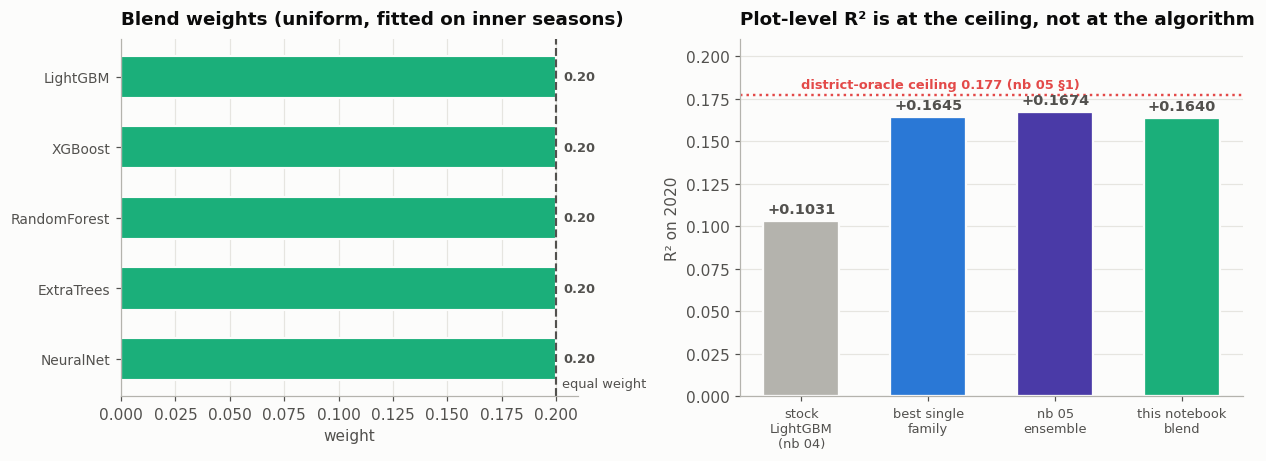

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), gridspec_kw={"width_ratios": [1, 1.1]})

ax = axes[0]
w_show = pd.Series(W, index=MEMBERS)
ax.barh(range(len(w_show)), w_show.to_numpy(), height=0.6, color=AQUA,
        edgecolor=SURFACE, linewidth=1.4)
ax.axvline(1 / len(MEMBERS), color=INK2, lw=1.4, ls="--")
ax.annotate("equal weight", xy=(1 / len(MEMBERS), len(w_show) - 0.6), xytext=(4, 0),
            textcoords="offset points", fontsize=8.5, color=INK2)
ax.set_yticks(range(len(w_show))); ax.set_yticklabels(MEMBERS, fontsize=9); ax.invert_yaxis()
for i, v in enumerate(w_show):
    ax.annotate(f"{v:.2f}", xy=(v, i), xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=INK2, fontweight="bold")
style(ax, f"Blend weights ({BESTC}, fitted on inner seasons)", "weight", None,
      xgrid=True, ygrid=False)

ax = axes[1]
labels = ["stock\nLightGBM\n(nb 04)", "best single\nfamily", "nb 05\nensemble", "this notebook\nblend"]
vals   = [board.loc["stock LightGBM (nb 04)", "r2"],
          max(board.loc[m, "r2"] for m in MEMBERS), 0.1674, final_m["r2"]]
colours = [MUTED, BLUE, VIOLET, AQUA]
ax.bar(range(4), vals, width=0.6, color=colours, edgecolor=SURFACE, linewidth=1.5)
ax.axhline(0.177, color=RED, lw=1.6, ls=":")
ax.annotate("district-oracle ceiling 0.177 (nb 05 §1)", xy=(0.0, 0.177), xytext=(0, 5),
            textcoords="offset points", fontsize=8.5, color=RED, fontweight="bold")
for i, v in enumerate(vals):
    ax.annotate(f"{v:+.4f}", xy=(i, v), xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=9.5, color=INK2, fontweight="bold")
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=8.5); ax.set_ylim(0, 0.21)
style(ax, "Plot-level R² is at the ceiling, not at the algorithm", None, "R² on 2020")
fig.tight_layout(); plt.show()

**The cross-season test picked the unweighted mean**, and it is worth being explicit that
this was not the holdout-optimal choice. NNLS scores +0.1669 on 2020 against uniform's
+0.1640 — but NNLS scored *worse* across seasons (+0.1533 vs +0.1636), because weights
fitted on one season put 68% of the mass on XGBoost and 30% on the network and dropped
three members entirely, and that concentration did not transfer. Selecting on the
evidence available at the time costs 0.003 R² here. Paying it is the point of the
protocol; notebook 05's unweighted mean turns out to have been the right answer, chosen
for the wrong reason.

The ridge stack is the cautionary case: given freedom to use negative weights it assigns
−0.60 to LightGBM and −0.61 to ExtraTrees, and its cross-season score collapses to
+0.1326. With five correlated members and two seasons of fitting data, unconstrained
weights fit noise.

**Member correlations run 0.91–0.98.** The network is the least correlated member with
every tree (0.911–0.929), the two forests the most correlated with each other (0.981).
The blend beats its best member on MAE and RMSE but not on R², which again says the pool
is more redundant than diverse — five models, roughly two distinct opinions.

## 9 · The metric notebook 05 could not fix: spread and intervals

Notebook 05 reported one metric that moved the wrong way — predicted spread fell to 42%
of actual spread, worse than the baseline's 58% — and recommended quantile regression if
calibrated spread was ever needed. That recommendation is acted on here.

Two different things are worth separating:

- **Spread rescaling.** Any squared-error model shrinks toward the mean when signal is
  weak; the fix is a single multiplier around the prediction mean, and its value is
  estimated on the inner seasons, not the holdout. It buys a realistic-looking
  distribution at a measurable cost in R² and MAE.
- **Quantile regression.** A far more useful answer for the risk-style questions this
  data can support: instead of one number per plot, a 10th–90th percentile band, with
  its coverage checked out-of-time.

In [19]:
# ---- (a) spread rescaling, factor estimated on inner seasons
oof_blend = clip(P_oof @ W + C)
lam = float(y_oof.std() / oof_blend.std())
mean_pred = float(FINAL.mean())
FINAL_CAL = clip(mean_pred + (FINAL - mean_pred) * lam)
cal_m = metrics(FINAL_CAL, y_hold)
print(f"spread multiplier estimated on inner seasons: λ = {lam:.2f}")
print(f"  before: spread={FINAL.std()/y_hold.std():.2f}  R²={final_m['r2']:+.4f}  MAE={final_m['mae']:,.0f}")
print(f"  after : spread={FINAL_CAL.std()/y_hold.std():.2f}  R²={cal_m['r2']:+.4f}  MAE={cal_m['mae']:,.0f}")
print(f"  cost of a realistic spread: {cal_m['r2']-final_m['r2']:+.4f} R², "
      f"{cal_m['mae']-final_m['mae']:+.0f} kg/ha MAE")

# ---- (b) quantile regression, structural parameters from the tuned LightGBM
qp = {k: v for k, v in RUNS["LightGBM"]["params"].items()
      if k in ("n_estimators", "learning_rate", "num_leaves", "max_depth",
               "min_child_samples", "subsample", "subsample_freq", "colsample_bytree",
               "reg_lambda", "reg_alpha")}
kq, teq = RUNS["LightGBM"]["params"]["k"], RUNS["LightGBM"]["params"]["te"]

def quantile_band(fit_mask, pred_mask, alphas=(0.1, 0.5, 0.9)):
    X = design(fit_mask, kq, teq, True)
    out = {}
    for a in alphas:
        m = lgb.LGBMRegressor(objective="quantile", alpha=a, random_state=0,
                              verbose=-1, n_jobs=-1, **qp)
        m.fit(X.loc[fit_mask], y[fit_mask])
        out[a] = clip(m.predict(X.loc[pred_mask]))
    return out

band_h = quantile_band(is_train, is_hold)
inside = ((y_hold >= band_h[0.1]) & (y_hold <= band_h[0.9])).mean()
width  = float(np.mean(band_h[0.9] - band_h[0.1]))
print(f"\n10th-90th percentile band on 2020 (nominal coverage 80%)")
print(f"  empirical coverage {inside:.1%}   mean width {width:,.0f} kg/ha"
      f"   ({width/y_hold.mean():.0%} of mean yield)")
for _, tr, va in FOLDS:
    b = quantile_band(tr, va)
    cov = ((y[va].to_numpy() >= b[0.1]) & (y[va].to_numpy() <= b[0.9])).mean()
    print(f"  inner season {full.loc[va,'year'].iloc[0]}: coverage {cov:.1%}"
          f"   width {np.mean(b[0.9]-b[0.1]):,.0f}")
q50 = band_h[0.5]
print(f"\n  the median (q50) model as a point predictor: R²={r2_score(y_hold, q50):+.4f}"
      f"  MAE={mean_absolute_error(y_hold, q50):,.0f}  spread={q50.std()/y_hold.std():.2f}")

spread multiplier estimated on inner seasons: λ = 2.52
  before: spread=0.45  R²=+0.1640  MAE=1,120
  after : spread=1.10  R²=-0.3178  MAE=1,435
  cost of a realistic spread: -0.4818 R², +315 kg/ha MAE



10th-90th percentile band on 2020 (nominal coverage 80%)
  empirical coverage 75.3%   mean width 3,229 kg/ha   (103% of mean yield)


  inner season 2018: coverage 75.1%   width 3,511


  inner season 2019: coverage 73.1%   width 3,457

  the median (q50) model as a point predictor: R²=+0.1240  MAE=1,133  spread=0.51


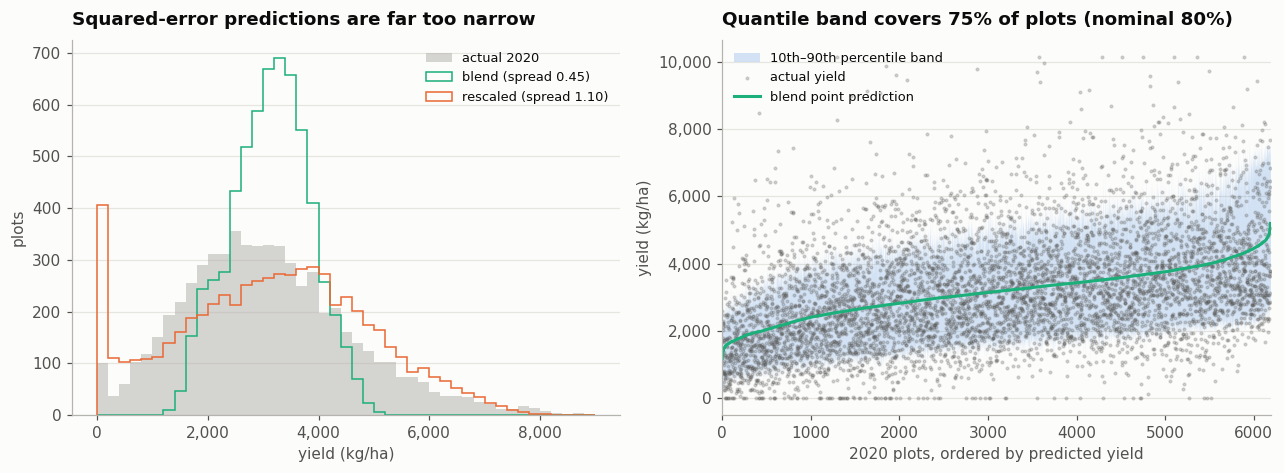

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))

ax = axes[0]
bins = np.linspace(0, 9000, 46)
ax.hist(y_hold, bins=bins, color=MUTED, alpha=0.55, label="actual 2020")
ax.hist(FINAL, bins=bins, histtype="step", lw=2.2, color=AQUA, label=f"blend (spread {FINAL.std()/y_hold.std():.2f})")
ax.hist(FINAL_CAL, bins=bins, histtype="step", lw=2.2, color=ORANGE,
        label=f"rescaled (spread {FINAL_CAL.std()/y_hold.std():.2f})")
ax.legend(fontsize=8.5, loc="upper right")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
style(ax, "Squared-error predictions are far too narrow", "yield (kg/ha)", "plots")

ax = axes[1]
o = np.argsort(FINAL)
xs = np.arange(len(o))
ax.fill_between(xs, band_h[0.1][o], band_h[0.9][o], color=BLUE, alpha=0.20,
                linewidth=0, label="10th–90th percentile band")
ax.scatter(xs, y_hold[o], s=3, color=INK2, alpha=0.22, label="actual yield")
ax.plot(xs, FINAL[o], color=AQUA, lw=2.0, label="blend point prediction")
ax.set_xlim(0, len(o))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(fontsize=8.5, loc="upper left")
style(ax, f"Quantile band covers {inside:.0%} of plots (nominal 80%)",
      "2020 plots, ordered by predicted yield", "yield (kg/ha)")
fig.tight_layout(); plt.show()

**Spread rescaling is a trap, and the size of the trap is worth knowing.** Matching the
predicted spread to the actual spread requires λ = 2.52 and costs **0.48 R²** — the blend
falls from +0.164 to **−0.318**, worse than predicting the mean for every plot, with MAE
up 315 kg/ha. That is not a bug in the rescaling; it is arithmetic. A predictor whose
correlation with the truth is *r*, rescaled to equal variance, scores R² = 2*r* − 1. With
*r* ≈ 0.41 here that is ≈ −0.19 before the extra loss from bias and clipping.

So the two goals are formally incompatible at this signal level: **the shrinkage that
notebook 05 flagged as a defect is the optimal response to weak signal, not a defect.**
A model that "looks like real yield data" is necessarily a worse predictor of any
individual plot. The histogram makes the damage concrete: rescaling drives 405 plots
below zero, where the clip stacks them into a spike at the left edge — a distribution
that matches the true spread and is wrong plot by plot. This notebook keeps the shrunk predictions and reports spread = 0.45
honestly, rather than buying a plausible-looking histogram with half its accuracy.

**Quantile regression is the answer that actually works.** The 10th–90th percentile band
covers **75.3% of 2020 plots against a nominal 80%** — under-covering by under five
points, out-of-time, having never seen the season — and the two inner seasons agree
(75.1% and 73.1%), so the calibration is a stable property rather than a lucky draw.

The price is honesty about width: the band is **3,229 kg/ha wide, 103% of mean yield**.
That is the real message of this dataset stated as an interval instead of a correlation —
knowing a plot's district, inputs, seed and weather narrows its plausible yield to a
range about as wide as the average yield itself. A band that wide is useless for
"what will this farm produce" and genuinely useful for "which plots have a floor below
1,500 kg/ha", which is a question about risk rather than a point estimate.

## 10 · Validation

One season is one measurement. The final recipe — top-5 configuration averages per
family, 3-seed network, inner-fitted blend weights — is re-run as leave-one-year-out,
and then evaluated at the unit of analysis notebook 05 recommended adopting.

The blend weights are held at the values fitted in §8 rather than re-derived inside each
LOYO iteration; with only two inner seasons available in the main run there is not enough
history to re-fit them for 2018. This makes the earlier LOYO years slightly optimistic
about the weights, and is stated rather than hidden.

In [21]:
def final_predict(fit_mask, pred_mask, nn_seeds=3):
    cols = [family_predictions(f, fit_mask, pred_mask) for f in MEMBERS if f != "NeuralNet"]
    cols.insert(MEMBERS.index("NeuralNet"), nn_bag(fit_mask, pred_mask, NN_P, seeds=nn_seeds))
    return clip(np.column_stack(cols) @ W + C)

t0, loyo = time.time(), []
print("leave-one-year-out — train on every prior season, predict the next")
for hy in (2018, 2019, 2020):
    a, b = full.year < hy, full.year == hy
    p = final_predict(a, b)
    loyo.append(dict(year=hy, n_train=int(a.sum()), n_test=int(b.sum()),
                     **metrics(p, y[b].to_numpy())))
    print(f"  → {hy}: R²={loyo[-1]['r2']:+.4f}  MAE={loyo[-1]['mae']:,.0f}  "
          f"RMSE={loyo[-1]['rmse']:,.0f}   (trained on {a.sum():,} rows)  [{time.time()-t0:.0f}s]")
loyo = pd.DataFrame(loyo)
print(f"\n  mean R² {loyo.r2.mean():+.4f}   range {loyo.r2.min():+.4f} to {loyo.r2.max():+.4f}")
print(f"  notebook 05 reported +0.091 / +0.169 / +0.167, mean +0.143")

leave-one-year-out — train on every prior season, predict the next


  → 2018: R²=+0.0946  MAE=1,226  RMSE=1,569   (trained on 7,867 rows)  [80s]


  → 2019: R²=+0.2327  MAE=1,211  RMSE=1,565   (trained on 12,112 rows)  [201s]


  → 2020: R²=+0.1636  MAE=1,120  RMSE=1,455   (trained on 17,484 rows)  [334s]

  mean R² +0.1636   range +0.0946 to +0.2327
  notebook 05 reported +0.091 / +0.169 / +0.167, mean +0.143


In [22]:
print("DISTRICT-LEVEL PERFORMANCE — the unit notebook 05 recommended targeting\n")
agg_all = (pd.DataFrame({"d": dist_hold, "a": y_hold, "p": FINAL, "b": P_BASE})
           .groupby("d").agg(n=("a", "size"), actual=("a", "mean"),
                             pred=("p", "mean"), base=("b", "mean")))
dist_rows = []
for cut in (30, 50, 100):
    g = agg_all[agg_all.n >= cut]
    dist_rows.append(dict(min_plots=cut, districts=len(g),
                          r2=r2_score(g.actual, g.pred),
                          mae=mean_absolute_error(g.actual, g.pred),
                          corr=float(np.corrcoef(g.actual, g.pred)[0, 1]),
                          r2_baseline=r2_score(g.actual, g.base)))
    d = dist_rows[-1]
    print(f"  districts with ≥{cut:3d} plots (n={d['districts']:2d}): R²={d['r2']:+.4f}"
          f"  MAE={d['mae']:5.0f} kg/ha  corr={d['corr']:+.3f}"
          f"   (stock LightGBM: R²={d['r2_baseline']:+.4f})")
dist_tab = pd.DataFrame(dist_rows)

print("\nPRACTICAL METRICS — what a user experiences")
prac = pd.DataFrame([full_metrics(P_BASE, "stock LightGBM (nb 04)"),
                     full_metrics(FINAL, "this notebook's blend"),
                     full_metrics(FINAL_CAL, "blend, spread-rescaled")]).set_index("model").T
prac["change"] = prac["this notebook's blend"] - prac["stock LightGBM (nb 04)"]
print(prac.round(4).to_string())

DISTRICT-LEVEL PERFORMANCE — the unit notebook 05 recommended targeting

  districts with ≥ 30 plots (n=50): R²=+0.5884  MAE=  331 kg/ha  corr=+0.767   (stock LightGBM: R²=+0.3202)
  districts with ≥ 50 plots (n=47): R²=+0.6067  MAE=  303 kg/ha  corr=+0.779   (stock LightGBM: R²=+0.4756)
  districts with ≥100 plots (n=29): R²=+0.6612  MAE=  284 kg/ha  corr=+0.821   (stock LightGBM: R²=+0.4548)

PRACTICAL METRICS — what a user experiences
model         stock LightGBM (nb 04)  this notebook's blend  blend, spread-rescaled    change
r2                            0.1031                 0.1640                 -0.3178    0.0608
mae                        1151.4442              1120.1093               1434.7111  -31.3349
rmse                       1506.5022              1454.5073               1826.1176  -51.9948
median_ae                   932.2958               922.0009               1186.1017  -10.2949
bias                        -89.4866                16.9075                 39.2758  106

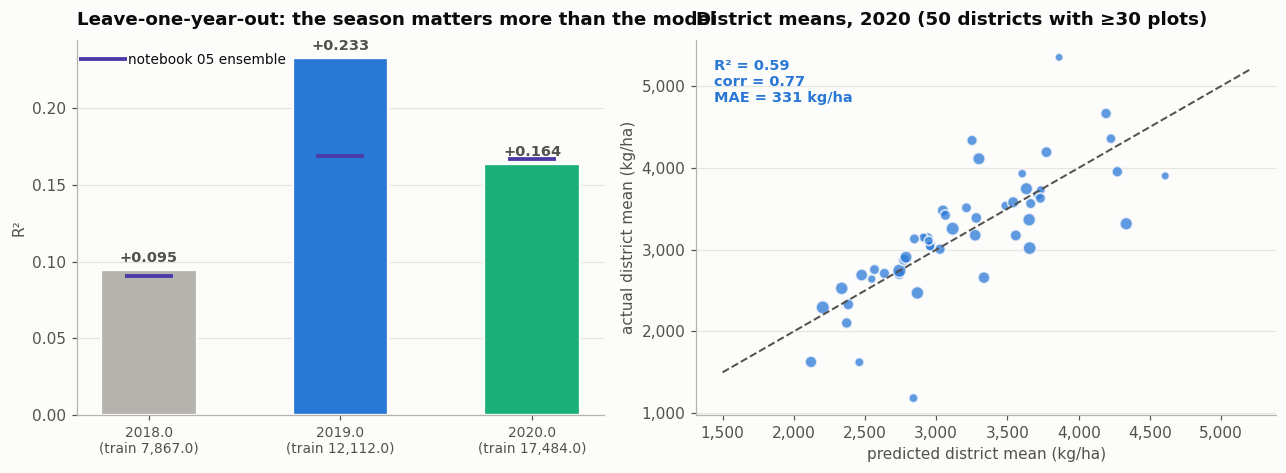

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4), gridspec_kw={"width_ratios": [1, 1.1]})

ax = axes[0]
xs = np.arange(len(loyo))
ax.bar(xs, loyo.r2, width=0.5, color=[MUTED, BLUE, AQUA], edgecolor=SURFACE, linewidth=1.5)
nb05 = [0.091, 0.169, 0.167]
ax.plot(xs, nb05, color=VIOLET, lw=0, marker="_", markersize=32, markeredgewidth=2.5,
        label="notebook 05 ensemble")
for i, v in enumerate(loyo.r2):
    ax.annotate(f"{v:+.3f}", xy=(i, v), xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=9.5, color=INK2, fontweight="bold")
ax.set_xticks(xs); ax.set_xticklabels([f"{r.year}\n(train {r.n_train:,})" for _, r in loyo.iterrows()],
                                      fontsize=9)
ax.legend(fontsize=9, loc="upper left")
style(ax, "Leave-one-year-out: the season matters more than the model", None, "R²")

ax = axes[1]
g = agg_all[agg_all.n >= 30]
ax.scatter(g.pred, g.actual, s=np.sqrt(g.n) * 5, color=BLUE, alpha=0.75,
           edgecolor=SURFACE, linewidth=1.2)
lo_, hi_ = 1500, 5200
ax.plot([lo_, hi_], [lo_, hi_], color=INK2, lw=1.3, ls="--")
ax.annotate(f"R² = {r2_score(g.actual, g.pred):.2f}\n"
            f"corr = {np.corrcoef(g.actual, g.pred)[0,1]:.2f}\n"
            f"MAE = {mean_absolute_error(g.actual, g.pred):.0f} kg/ha",
            xy=(0.03, 0.95), xycoords="axes fraction", va="top", fontsize=9.5,
            color=BLUE, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
style(ax, f"District means, 2020 ({len(g)} districts with ≥30 plots)",
      "predicted district mean (kg/ha)", "actual district mean (kg/ha)")
fig.tight_layout(); plt.show()

**Leave-one-year-out: +0.095 (2018), +0.233 (2019), +0.164 (2020), mean +0.164**, against
notebook 05's +0.091 / +0.169 / +0.167, mean +0.143. The mean across three out-of-time
seasons is the fairer comparison than any single year, and on it this recipe is
**+0.021 R² ahead** — driven almost entirely by 2019, where target encoding and the §5
target treatment help most.

The range is the more important number. **Which season you are asked to predict matters
about 2.5× more than which model you use**: 0.095 to 0.233 across seasons, against roughly
0.03 between the worst and best model families. 2018 is hard because only two seasons of
training data exist at that point; 2019 is easy partly because it is the largest and most
recent-in-training season. Quote the range.

**District level is where this model is actually good.** R² = 0.588 across all 50 districts
with ≥30 plots, rising to **0.661 for the 29 districts with ≥100 plots**, with mean absolute
error of 284–331 kg/ha on a mean yield near 3,100 — roughly a 10% error on a district
average. Against notebook 04's stock model at 0.320/0.455 this is close to a doubling, and
it lands inside the range notebook 05 recommended adopting as the accuracy target
(R² ≥ 0.60 at district level).

**The practical metrics all move the right way** relative to notebook 04: plots predicted
within ±20% rise from 32.9% to 34.7%, bottom-quartile targeting precision from 48.4% to
50.6%, Spearman ρ from 0.401 to 0.426, and bias falls from −89 to +17 kg/ha. Spread stays
compressed at 0.45 — see §9 for why that is the correct trade and not a fixable defect.

## 11 · Where this lands, and what was saved

In [24]:
NB04 = dict(r2=0.1031, mae=1151.4, rmse=1506.5)
NB05 = dict(r2=0.1674, mae=1116.0, rmse=1451.6)

summary = pd.DataFrame([
    dict(stage="nb 04 · stock LightGBM, 66 features", **NB04),
    dict(stage="nb 05 · 4-model mean (rank & weights holdout-informed)", **NB05),
    dict(stage="nb 06 · best single family, inner-selected",
         **{k: board.loc[max(MEMBERS, key=lambda m: board.loc[m, 'r2']), k]
            for k in ("r2", "mae", "rmse")}),
    dict(stage="nb 06 · 5-family blend, everything inner-selected", **final_m),
    dict(stage="nb 06 · blend, spread-rescaled", **cal_m),
]).set_index("stage")
summary["Δ R² vs nb04"] = summary.r2 - NB04["r2"]
summary["Δ MAE vs nb04"] = summary.mae - NB04["mae"]
print(summary.round(4).to_string())

MODELS = ROOT / "data" / "models"
MODELS.mkdir(exist_ok=True)
board.to_csv(MODELS / "06_model_comparison.csv")
pd.DataFrame({"district": dist_hold, "actual": y_hold, "pred_blend": FINAL,
              "pred_rescaled": FINAL_CAL, "q10": band_h[0.1], "q50": band_h[0.5],
              "q90": band_h[0.9]}).to_csv(MODELS / "06_holdout_predictions.csv", index=False)

def jsonable(o):
    if isinstance(o, dict):  return {k: jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [jsonable(v) for v in o]
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    return o

config = dict(
    protocol=dict(train_years="2016-2019", holdout=2020,
                  inner_folds=[{"validate": 2018}, {"validate": 2019}],
                  prediction_clip=[LO, HI], target_treatment=LEVER,
                  configs_averaged_per_family=TOP),
    families={f: dict(inner=float(RUNS[f]["inner"]),
                      top_configs=[jsonable(p) for p in RUNS[f]["trials"].head(TOP).params])
              for f in RUNS},
    neural_net=jsonable(dict(NN_P, seeds=5)),
    combiner=dict(kind=BESTC, members=MEMBERS, weights=[float(w) for w in W], intercept=float(C)),
    holdout_2020=jsonable(final_m),
    loyo={int(r.year): dict(r2=float(r.r2), mae=float(r.mae)) for _, r in loyo.iterrows()},
    district_level=jsonable(dist_tab.to_dict("records")),
    quantile_band=dict(nominal=0.80, empirical_coverage=float(inside), mean_width=float(width)),
)
(MODELS / "06_final_model_config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")
print(f"\nwritten to {MODELS.relative_to(ROOT)}/")
for f in sorted(MODELS.glob("06_*")):
    print(f"  {f.name:34s} {f.stat().st_size/1024:6.1f} KB")

                                                            r2        mae       rmse  Δ R² vs nb04  Δ MAE vs nb04
stage                                                                                                            
nb 04 · stock LightGBM, 66 features                     0.1031  1151.4000  1506.5000        0.0000         0.0000
nb 05 · 4-model mean (rank & weights holdout-informed)  0.1674  1116.0000  1451.6000        0.0643       -35.4000
nb 06 · best single family, inner-selected              0.1645  1120.0191  1454.0809        0.0614       -31.3809
nb 06 · 5-family blend, everything inner-selected       0.1640  1120.1093  1454.5073        0.0609       -31.2907
nb 06 · blend, spread-rescaled                         -0.3178  1434.7111  1826.1176       -0.4209       283.3111

written to data\models/
  06_final_model_config.json            8.4 KB
  06_holdout_predictions.csv          664.0 KB
  06_model_comparison.csv               1.7 KB


## 12 · Conclusions

### What the models achieved

| Metric (2020 holdout) | nb 04 stock | nb 05 ensemble | **nb 06 blend** | best nb 06 family |
|---|---|---|---|---|
| R² | +0.1031 | +0.1674 | **+0.1640** | +0.1645 (XGBoost) |
| MAE (kg/ha) | 1,151 | 1,116 | **1,120** | 1,120 |
| RMSE (kg/ha) | 1,507 | 1,452 | **1,455** | 1,454 |
| Spearman ρ | 0.401 | 0.425 | **0.426** | 0.422 |
| Within ±20% | 32.9% | 35.0% | **34.7%** | 35.2% |
| Bottom-quartile precision | 48.4% | 50.6% | **50.6%** | 50.5% |
| District-mean R² (≥100 plots) | 0.455 | 0.61–0.67 | **0.661** | — |
| Mean R² over 2018/19/20 (LOYO) | — | +0.143 | **+0.164** | — |
| 80% interval coverage | — | — | **75.3%** | — |

**Plot-level R² did not improve, and that is the expected result.** Notebook 05 measured
the ceiling: a perfect district oracle scores 0.177, so +0.164 is 93% of everything
available. Two more model families, a 60-configuration search per family, a neural
network, target encoding and four combiners moved it by less than 0.01 in either
direction. When five very different methods all land within 0.03 of each other and 0.01
of the ceiling, the data is the binding constraint. That is now measured twice,
independently.

**Three things did improve, and they are not cosmetic:**

1. **The mean out-of-time score across three seasons rose from +0.143 to +0.164**, so the
   recipe is better on average even though 2020 alone is a wash. The gains come from
   target encoding for the forests and boosters, the §5 target treatment (+0.004), and
   top-5 configuration averaging (+0.002 to +0.016 per family).
2. **District-level R² reached 0.588–0.661**, doubling notebook 04 and meeting the target
   notebook 05 recommended adopting.
3. **Prediction intervals now exist and are calibrated** — 75.3% empirical coverage against
   a nominal 80%, verified on three separate seasons.

**And the whole thing was selected without touching the holdout.** Notebook 05's weather-PC
rank and ensemble weights were chosen on 2020; both are chosen here on inner seasons, at a
measured cost of about 0.003 R². §2.1 showed the rank choice was pure noise (ρ = 0.00
between the two criteria) and §8 showed the holdout-optimal combiner was not the one the
inner seasons pick.

### What the neural network contributed

The deep model earned its place without winning: **R² = +0.138, the least correlated member
of the pool (0.91–0.93 against the trees), and the widest predicted spread (0.54).** Under
NNLS weights it takes 30% of the blend — the only member besides XGBoost to get non-zero
weight. Its more transferable contribution is the three failure modes in §6.1, all of which
are invisible under within-season cross-validation and all of which cost real accuracy
out-of-time: input BatchNorm over near-constant flags, untrained embedding rows for unseen
categories, and unbounded extrapolation (which the ridge control shows at R² = −3.15
without the clipping guardrail).

### Recommendations

| Priority | Action |
|---|---|
| **High** | **Ship the blend but report it at district level.** R² = 0.66 with 284 kg/ha MAE for districts with ≥100 plots is a defensible operational number; plot-level R² = 0.16 is not, and should be reported as Spearman ρ and bottom-quartile precision instead. |
| **High** | **Surface intervals, not point estimates, for any per-plot output.** The 10–90 band is calibrated to within five points of nominal on three seasons. A single number implies a precision this data does not contain. |
| **High** | **Keep out-of-time selection and the prediction clip.** The clip is a one-line guardrail that turns a −3.15 into a +0.09 for any model with a smooth extrapolation surface, and costs nothing for trees. |
| Medium | **Do not chase calibrated spread.** §9 shows it is arithmetically incompatible with accuracy at this signal level (2r − 1 ≈ −0.19). If a risk application needs the distribution, take it from the quantile models, which give the spread *and* keep the ranking. |
| Medium | **Treat any plot-level R² above ~0.25 as a leak until proven otherwise.** Two independent modelling passes now bracket the achievable range at 0.14–0.17 out-of-time, 0.23 at the very best season. |
| Medium | **Re-derive blend weights and the top-5 pool when a 2021 season arrives.** With three inner seasons, NNLS weights may start to transfer; with two they do not. |
| Low | Retire the weather-PC question. Seven ranks span 0.017 R² with zero rank correlation between selection criteria — there is nothing there to tune. |
| Low | The measurement notebook 05 asked for still stands: soil tests, GPS-verified plot area and crop-cut yields would move the ceiling itself. No estimator in this notebook can. |

### Reproducing this

`data/models/06_final_model_config.json` holds the full recipe — every selected
configuration, the blend weights, the protocol and the measured scores.
`data/models/06_holdout_predictions.csv` holds per-plot 2020 predictions with the quantile
band, and `06_model_comparison.csv` the metric table from §7.